In [1]:
# @title 폰트 설정 및 라이브러리 추가
import os
import re
import glob
import shutil
import random

import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F

import torchvision.transforms.functional as TF

from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

!apt-get -qq install fonts-nanum > /dev/null

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료:", plt.rcParams['font.family'])

PyTorch: 2.11.0+cu128
CUDA: True
Device: Tesla T4
폰트 설정 완료: ['NanumGothic']


In [3]:
# @title 파일 불러오기 (사용자 환경에 따라 수정이 필요합니다.)
if not any('Nanum' in f.name for f in fm.fontManager.ttflist):
    os.system("apt-get -qq install fonts-nanum > /dev/null 2>&1")
    fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

from google.colab import drive
drive.mount("/content/drive")

SRC = "/content/drive/MyDrive/every_define/crop"
DATA_DIR = "/content/dataset"
IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

if not os.path.isdir(SRC):
    found = glob.glob("/content/drive/MyDrive/**/every_define/crop", recursive=True)
    assert found, "MyDrive 안에서 'every_define/crop' 폴더를 찾지 못함 — 폴더명/위치 확인"
    SRC = found[0]
print("데이터 폴더:", SRC)

marker_path = os.path.join(DATA_DIR, ".src_marker")
need_copy = True
if os.path.exists(DATA_DIR) and os.path.exists(marker_path):
    with open(marker_path) as f:
        prev_src = f.read().strip()
    if prev_src == SRC and len(os.listdir(DATA_DIR)) > 1:
        need_copy = False

if need_copy:
    if os.path.exists(DATA_DIR):
        shutil.rmtree(DATA_DIR)
    os.makedirs(DATA_DIR, exist_ok=True)
    copied = 0
    for root, dirs, files in os.walk(SRC, followlinks=False):
        dirs[:] = [d for d in dirs if not os.path.islink(os.path.join(root, d))]
        rel = os.path.relpath(root, SRC)
        for f in files:
            if f.lower().endswith(IMG_EXTS):
                dst_dir = DATA_DIR if rel == "." else os.path.join(DATA_DIR, rel)
                os.makedirs(dst_dir, exist_ok=True)
                shutil.copy2(os.path.join(root, f), os.path.join(dst_dir, f))
                copied += 1
    with open(marker_path, "w") as f:
        f.write(SRC)
    print(f"복사 완료: {copied}장  (source: {SRC})")
else:
    n = sum(1 for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
            if p.lower().endswith(IMG_EXTS))
    print(f"이미 준비됨({SRC} 기준): {n}장")

Mounted at /content/drive
데이터 폴더: /content/drive/MyDrive/every_define/crop
복사 완료: 4122장  (source: /content/drive/MyDrive/every_define/crop)


In [4]:
# @title 5um 입자 픽셀 처리
ORIG_W = 800
FOV_UM = None
VER2_RESIZE = 256

def defect_px(fov_um, orig_w=ORIG_W, defect_um=5):
    um_per_px = fov_um / orig_w
    orig_px = defect_um / um_per_px
    resized_px = orig_px * VER2_RESIZE / orig_w
    return um_per_px, orig_px, resized_px

if FOV_UM is not None:
    u, o, r = defect_px(FOV_UM)
    print(f"um/pixel               : {u:.3f}")
    print(f"5um 결함 (원본 해상도) : {o:.1f} px")
    print(f"5um 결함 (256 resize)  : {r:.2f} px   <- ver2 방식")
else:
    print("FOV_UM 미확인 — 촬영 배율/시야 확인 후 값을 넣을 것. 후보 시나리오:")
    print(f"{'FOV(um)':>8} {'um/px':>7} {'5um(원본 px)':>12} {'5um(256 resize px)':>18}")
    for fov in [200, 400, 800, 1600, 3200]:
        u, o, r = defect_px(fov)
        print(f"{fov:>8} {u:>7.2f} {o:>12.1f} {r:>18.2f}")

print()
print(f" - 원본 {ORIG_W}x{ORIG_W} -> 256 resize 시 {ORIG_W / VER2_RESIZE:.2f}배 축소")
print(" - 256 resize에서 5um가 1~2px 이하면 resize 방식으로는 검출 불가 -> patch 방식 근거")
print(" - patch 방식에서는 5um 결함의 원본 픽셀 수가 그대로 보존됨")

FOV_UM 미확인 — 촬영 배율/시야 확인 후 값을 넣을 것. 후보 시나리오:
 FOV(um)   um/px   5um(원본 px) 5um(256 resize px)
     200    0.25         20.0               6.40
     400    0.50         10.0               3.20
     800    1.00          5.0               1.60
    1600    2.00          2.5               0.80
    3200    4.00          1.2               0.40

 - 원본 800x800 -> 256 resize 시 3.12배 축소
 - 256 resize에서 5um가 1~2px 이하면 resize 방식으로는 검출 불가 -> patch 방식 근거
 - patch 방식에서는 5um 결함의 원본 픽셀 수가 그대로 보존됨


In [5]:
# @title 학습/검증 데이터 분리
import unicodedata
from collections import Counter

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")
DIE_ONLY = True
MIN_PER_CLASS = 2
ORDER = "PSBC"
DROP_LETTERS = "BC"
BG_TAG = "p"
EXCLUDE_TAGS = set("UFXD")
REQUIRE_CLEAN_BG = False
UNKNOWN_CAUSE = "원인미상"
SKIP_NAMES = {"미지정", "미분류", "U", "F", "X", "D"}

USE = "".join(c for c in ORDER if c not in DROP_LETTERS)

def nfc(s):
    return unicodedata.normalize("NFC", s)

def suffix_of(path):
    parts = nfc(os.path.splitext(os.path.basename(path))[0]).split("-")
    return parts[3] if len(parts) >= 4 else ""

def canon(s):
    up = "".join(ch for ch in s if ch.isupper())
    return "".join(c for c in USE if c in up)

def token_of(path):
    suf = suffix_of(path)
    if set(suf) & EXCLUDE_TAGS:
        return None
    rel_dir = nfc(os.path.relpath(os.path.dirname(path), DATA_DIR))
    for part in reversed(rel_dir.split(os.sep)):
        if part in (".", ""):
            continue
        name = part.strip()
        if name in SKIP_NAMES or name.upper() in SKIP_NAMES:
            return None
        if name == "양품" or name.upper() == "G":
            return "양품"
        if set(name.upper()) <= set(ORDER) and canon(name):
            return canon(name)
    parts = nfc(os.path.splitext(os.path.basename(path))[0]).split("-")
    if "양" in parts:
        return "양품"
    if "불" in parts:
        return canon(suf) or UNKNOWN_CAUSE
    return None

all_files = sorted(
    p for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
    if p.lower().endswith(IMG_EXTS)
)

def is_die(path):
    return "die" in re.split(r"[^0-9a-z가-힣]+", os.path.basename(path).lower())

target = [p for p in all_files if (not DIE_ONLY or is_die(p))]
BG_OK = {p: (BG_TAG in suffix_of(p)) for p in target}
dropped_tag = [p for p in target if set(suffix_of(p)) & EXCLUDE_TAGS]

drop_cnt = Counter()
for p in dropped_tag:
    for ch in sorted(set(suffix_of(p)) & EXCLUDE_TAGS):
        drop_cnt[ch] += 1

pool = target if not REQUIRE_CLEAN_BG else [p for p in target if BG_OK[p]]
toks = {p: token_of(p) for p in pool}
labeled = [p for p in pool if toks[p] and toks[p] != UNKNOWN_CAUSE]
unknown_cause = [p for p in pool if toks[p] == UNKNOWN_CAUSE]
unlabeled = [p for p in pool if not toks[p] and p not in dropped_tag]

cnt = Counter(toks[p] for p in labeled)
defect_tokens = sorted((t for t in cnt if t != "양품"), key=lambda t: (len(t), t))
ALL_CLASSES = (["양품"] if cnt.get("양품") else []) + defect_tokens

print(f"사용 지표 {USE}" + (f"  (라벨 제외: {DROP_LETTERS})" if DROP_LETTERS else ""))
print(f"전체 {len(all_files)}장 / 대상 {len(target)}장 (DIE_ONLY={DIE_ONLY})")
print(f"배경 에러(p 없음) {sum(1 for p in target if not BG_OK[p])}장 — "
      f"현재 {'제외' if REQUIRE_CLEAN_BG else '포함'}")
print(f"태그 제외 {len(dropped_tag)}장 "
      f"{ {k: drop_cnt[k] for k in sorted(drop_cnt)} }  (D=X: 다이오드 사진 아님)\n")
print(f"{'클래스':12s} {'장수':>6s}")
for name in ALL_CLASSES:
    n = cnt[name]
    if n < MIN_PER_CLASS:
        note = f"  <- {MIN_PER_CLASS}장 미만: 학습 제외"
    elif n < 10:
        note = "  <- 표본 적음 주의"
    else:
        note = ""
    print(f"{name:12s} {n:>6d}{note}")
print(f"{'제외지표만':12s} {len(unknown_cause):>6d}   <- 볼 근거가 없어 학습 제외")
print(f"{'미지정/불명':12s} {len(unlabeled):>6d}   <- 학습 제외")

CLASS_NAMES = [t for t in ALL_CLASSES if cnt[t] >= MIN_PER_CLASS]
cls_paths = [sorted(p for p in labeled if toks[p] == t) for t in CLASS_NAMES]
labels = {p: (CLASS_NAMES.index(toks[p]) if toks[p] in CLASS_NAMES else None)
          for p in pool}

n_good = cnt.get("양품", 0)
n_bad_all = sum(v for k, v in cnt.items() if k != "양품")
print(f"\n학습 클래스 {len(CLASS_NAMES)}개: {CLASS_NAMES}")
print(f"양품 {n_good}장 / 불량 {n_bad_all}장 "
      f"(불량 비율 {n_bad_all / max(n_good + n_bad_all, 1):.1%})")
print(f"\n{'지표':6s} {'전체':>8s} {'배경정상':>9s}")
for L in USE:
    tot = sum(v for k, v in cnt.items() if k != "양품" and L in k)
    clean = sum(1 for p in labeled
                if toks[p] != "양품" and L in toks[p] and BG_OK[p])
    print(f"{L:6s} {tot:>8d} {clean:>9d}")

assert len(CLASS_NAMES) >= 2, "학습 가능한 클래스가 2개 미만 — 라벨/경로 확인"
for name, p in zip(CLASS_NAMES, cls_paths):
    assert len(p) >= 2, f"'{name}' 클래스가 {len(p)}장 — train/val 분리 불가"

사용 지표 PS  (라벨 제외: BC)
전체 4122장 / 대상 4122장 (DIE_ONLY=True)
배경 에러(p 없음) 1644장 — 현재 포함
태그 제외 413장 {'D': 187, 'F': 193, 'X': 33}  (D=X: 다이오드 사진 아님)

클래스              장수
양품             2130
P               327
S                20
PS               34
제외지표만          1198   <- 볼 근거가 없어 학습 제외
미지정/불명            0   <- 학습 제외

학습 클래스 4개: ['양품', 'P', 'S', 'PS']
양품 2130장 / 불량 381장 (불량 비율 15.2%)

지표           전체      배경정상
P           361       176
S            54         4


In [6]:
# @title 260731 이미지와 학습 데이터 실제 파일 겹침 확인 (해시 비교)
import hashlib

EXT_DIR_CHECK = "/content/drive/MyDrive/260731"

def file_md5(path, chunk=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

train_hashes = {}
for p in all_files:
    train_hashes[file_md5(p)] = p

ext_paths_check = sorted(p for p in glob.glob(os.path.join(EXT_DIR_CHECK, "**", "*"), recursive=True)
                         if p.lower().endswith(IMG_EXTS))

dup = [(p, train_hashes[file_md5(p)]) for p in ext_paths_check if file_md5(p) in train_hashes]
print(f"260731 이미지 {len(ext_paths_check)}장 중 학습 데이터 풀과 완전히 동일한 파일(MD5 일치) {len(dup)}장")
for p, tp in dup[:20]:
    print(f"  {os.path.basename(p):20s} == {os.path.basename(tp)}")

260731 이미지 788장 중 학습 데이터 풀과 완전히 동일한 파일(MD5 일치) 761장
  1.jpg                == 2-die-양-po.jpg
  1001.jpg             == 1005-die-양-po.jpg
  1004.jpg             == 1008-die-양-po.jpg
  1007.jpg             == 1017-die-양-po.jpg
  1015.jpg             == 1015-die-불-F.jpg
  1016.jpg             == 1016-die-불-F.jpg
  1017.jpg             == 1017-die-불-F.jpg
  1019.jpg             == 1035-die-양-po.jpg
  102.jpg              == 102-die-불-pP.jpg
  1027.jpg             == 1027-die-불-pB.jpg
  1028.jpg             == 1028-die-불-pB.jpg
  1031.jpg             == 1031-die-불-F.jpg
  1032.jpg             == 1032-die-불-pB.jpg
  1038.jpg             == 1038-die-불-F.jpg
  1043.jpg             == 1043-die-불-F.jpg
  1050.jpg             == 1050-die-양-po.jpg
  1053.jpg             == 1053-die-양-po.jpg
  1058.jpg             == 1058-die-불-S.jpg
  1061.jpg             == 1061-die-양-po.jpg
  1066.jpg             == 1066-die-불-F.jpg


In [7]:
# @title 260731 · 260721 공식 채점 대상 홀드아웃 분리 (학습 풀에서 제외)
import hashlib, csv

def file_md5(path, chunk=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def read_answer_csv(path):
    out = {}
    with open(path, encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            name = os.path.basename((row.get("파일") or row.get("파일명") or "").strip())
            if name:
                out[name] = row
    return out

def official_hashes(ext_dir, answer_csv):
    answers = read_answer_csv(answer_csv)
    hashes = set()
    for p in glob.glob(os.path.join(ext_dir, "**", "*"), recursive=True):
        if not p.lower().endswith(IMG_EXTS):
            continue
        name = os.path.basename(p)
        row = answers.get(name)
        if not row:
            continue
        target_flag = (row.get("채점대상") or "").strip()
        if target_flag.startswith("예"):
            hashes.add(file_md5(p))
    return hashes

HOLDOUT_260731 = official_hashes("/content/drive/MyDrive/260731", "/content/drive/MyDrive/정답지_260731.csv")
HOLDOUT_260721 = official_hashes("/content/drive/MyDrive/260721", "/content/drive/MyDrive/정답지_260721.csv")
HOLDOUT_HASHES = HOLDOUT_260731 | HOLDOUT_260721

pool_hash = {p: file_md5(p) for p in all_files}
held_out_set = {p for p in all_files if pool_hash[p] in HOLDOUT_HASHES}

before_counts = [len(paths) for paths in cls_paths]
cls_paths = [[p for p in paths if p not in held_out_set] for paths in cls_paths]
after_counts = [len(paths) for paths in cls_paths]

print(f"260731 채점대상 {len(HOLDOUT_260731)}종 + 260721 채점대상 {len(HOLDOUT_260721)}종 (해시 기준)")
print(f"학습 데이터 풀과 겹쳐서 제외한 이미지 {len(held_out_set)}장")
print(f"{'클래스':12s} {'기존':>6s} {'제외 후':>8s}")
for name, b, a in zip(CLASS_NAMES, before_counts, after_counts):
    print(f"{name:12s} {b:>6d} {a:>8d}")
print("\n이 셀 이후 cls_paths가 갱신되었으니, 뒤의 MIL 데이터셋 셀의 train/val/test 분할은 이 갱신된 cls_paths를 씁니다")

260731 채점대상 788종 + 260721 채점대상 347종 (해시 기준)
학습 데이터 풀과 겹쳐서 제외한 이미지 1108장
클래스              기존     제외 후
양품             2130     1828
P               327      168
S                20       13
PS               34       34

이 셀 이후 cls_paths가 갱신되었으니, 뒤의 MIL 데이터셋 셀의 train/val/test 분할은 이 갱신된 cls_paths를 씁니다


In [12]:
# @title 260721 정답지 라벨 학습 반영
import csv

EXT_DIR2 = "/content/drive/MyDrive/260721"
ANSWER_CSV2 = "/content/drive/MyDrive/정답지_260721.csv"
OFFICIAL_BAD_CLASS = "공식불량"

def read_answer_csv(path):
    out = {}
    with open(path, encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            name = os.path.basename((row.get("파일") or row.get("파일명") or "").strip())
            if name:
                out[name] = row
    return out

answers_721 = read_answer_csv(ANSWER_CSV2)
ext_paths_721 = sorted(p for p in glob.glob(os.path.join(EXT_DIR2, "**", "*"), recursive=True)
                       if p.lower().endswith(IMG_EXTS))

if answers_721:
    sample_row = next(iter(answers_721.values()))
    print(f"정답지 컬럼: {list(sample_row.keys())}")

add_good, add_bad, skipped = [], [], 0
for p in ext_paths_721:
    row = answers_721.get(os.path.basename(p))
    if not row:
        skipped += 1
        continue
    target_flag = (row.get("채점대상") or "").strip()
    if not target_flag.startswith("예"):
        skipped += 1
        continue
    label = (row.get("라벨") or "").strip()
    if "양품" in label:
        add_good.append(p)
    elif "불량" in label:
        add_bad.append(p)
    else:
        skipped += 1

good_idx = CLASS_NAMES.index("양품")
cls_paths[good_idx] = sorted(set(cls_paths[good_idx]) | set(add_good))

if OFFICIAL_BAD_CLASS not in CLASS_NAMES:
    CLASS_NAMES.append(OFFICIAL_BAD_CLASS)
    cls_paths.append([])
bad_idx = CLASS_NAMES.index(OFFICIAL_BAD_CLASS)
cls_paths[bad_idx] = sorted(set(cls_paths[bad_idx]) | set(add_bad))

print(f"260721 채점대상 이미지 {len(ext_paths_721)}장 중 반영 {len(add_good) + len(add_bad)}장 "
      f"(양품 {len(add_good)} / {OFFICIAL_BAD_CLASS} {len(add_bad)}) · 제외 {skipped}장")
print(f"학습 클래스 {len(CLASS_NAMES)}개: {CLASS_NAMES}")
for name, paths in zip(CLASS_NAMES, cls_paths):
    print(f"  {name:12s} {len(paths):>6d}")
print("\n주의: 260721은 이제 학습에 쓰였으니, 이후 '정답지 채점 (260721 배치)' 결과는 "
      "held-out 시험지가 아니라 참고용입니다. 260731만 순수 held-out으로 유지됩니다.")

정답지 컬럼: ['파일', '라벨', '채점대상', '라벨출처', '비고']
260721 채점대상 이미지 347장 중 반영 347장 (양품 241 / 공식불량 106) · 제외 0장
학습 클래스 5개: ['양품', 'P', 'S', 'PS', '공식불량']
  양품             2069
  P               168
  S                13
  PS               34
  공식불량            106

주의: 260721은 이제 학습에 쓰였으니, 이후 '정답지 채점 (260721 배치)' 결과는 held-out 시험지가 아니라 참고용입니다. 260731만 순수 held-out으로 유지됩니다.


In [13]:
# @title 자체 라벨 vs 정답지 라벨 태그별 일치도 분석
from collections import Counter, defaultdict

def official_rows(ext_dir, answer_csv):
    answers = read_answer_csv(answer_csv)
    out = {}
    for p in glob.glob(os.path.join(ext_dir, "**", "*"), recursive=True):
        if not p.lower().endswith(IMG_EXTS):
            continue
        name = os.path.basename(p)
        row = answers.get(name)
        if not row:
            continue
        if not (row.get("채점대상") or "").strip().startswith("예"):
            continue
        out[p] = (row.get("라벨") or "").strip()
    return out

hash_to_pool = {h: p for p, h in pool_hash.items()}

pairs = {}
for ext_dir, answer_csv in [("/content/drive/MyDrive/260731", "/content/drive/MyDrive/정답지_260731.csv"),
                            ("/content/drive/MyDrive/260721", "/content/drive/MyDrive/정답지_260721.csv")]:
    for p, official in official_rows(ext_dir, answer_csv).items():
        h = file_md5(p)
        tp = hash_to_pool.get(h)
        if tp is None:
            continue
        pairs[tp] = official

table = defaultdict(Counter)
for tp, official in pairs.items():
    raw = toks.get(tp)
    self_tag = raw if raw and raw != UNKNOWN_CAUSE else "미지정"
    table[self_tag]["불량" if "불량" in official else "양품"] += 1

print(f"정답지 라벨 확인 가능한 겹침 이미지 {len(pairs)}장 (260731+260721 채점대상=예 기준)\n")
print(f"{'자체 태그':10s} {'전체':>6s} {'정답지=불량':>10s} {'정답지=양품':>10s} {'기대와 일치율':>12s}")
order = ["양품"] + sorted((t for t in table if t not in ("양품", "미지정")), key=lambda t: (len(t), t))
if "미지정" in table:
    order.append("미지정")
agree_total = n_total = 0
for tag in order:
    c = table[tag]
    n = c["불량"] + c["양품"]
    n_total += n
    agree = c["양품"] if tag == "양품" else c["불량"]
    agree_total += agree
    rate = agree / n if n else 0.0
    print(f"{tag:10s} {n:>6d} {c['불량']:>10d} {c['양품']:>10d} {rate:>11.1%}")
print(f"\n전체 일치율 {agree_total}/{n_total} ({agree_total / max(n_total, 1):.1%})")

miss = table["양품"]["불량"]
over = sum(c["양품"] for t, c in table.items() if t != "양품")
print(f"자체=양품인데 정답지=불량 (놓친 불량) {miss}장")
print(f"자체=불량인데 정답지=양품 (과다 판정) {over}장")

print(f"\n지표별 (해당 지표가 포함된 자체 태그 기준) 정답지 불량 일치율")
print(f"{'지표':6s} {'전체':>6s} {'정답지=불량':>10s} {'정답지=양품':>10s} {'일치율':>8s}")
for L in USE:
    n = b = g = 0
    for tp, official in pairs.items():
        raw = toks.get(tp)
        tag = raw if raw and raw != UNKNOWN_CAUSE else None
        if tag and tag != "양품" and L in tag:
            n += 1
            if "불량" in official:
                b += 1
            else:
                g += 1
    if n:
        print(f"{L:6s} {n:>6d} {b:>10d} {g:>10d} {b / n:>7.1%}")

정답지 라벨 확인 가능한 겹침 이미지 1108장 (260731+260721 채점대상=예 기준)

자체 태그          전체     정답지=불량     정답지=양품      기대와 일치율
양품            302         21        281       93.0%
P             159         57        102       35.8%
S               7          1          6       14.3%
미지정           640        142        498       22.2%

전체 일치율 481/1108 (43.4%)
자체=양품인데 정답지=불량 (놓친 불량) 21장
자체=불량인데 정답지=양품 (과다 판정) 606장

지표별 (해당 지표가 포함된 자체 태그 기준) 정답지 불량 일치율
지표         전체     정답지=불량     정답지=양품      일치율
P         159         57        102   35.8%
S           7          1          6   14.3%


In [14]:
# @title 제외 소자 목록 내보내기
import csv

EXCL_OUT = "phosem_v3_excluded.csv"

def excl_reason(p):
    tags = set(suffix_of(p)) & EXCLUDE_TAGS
    if tags:
        return "태그 제외 (" + "/".join(sorted(tags)) + ")"
    if toks.get(p) == UNKNOWN_CAUSE:
        return "원인미상 (볼 근거 없음)"
    return "라벨 미확정"

non_die = [p for p in all_files if p not in target]
excl_rows = ([(p, "die 파일 아님") for p in non_die]
             + [(p, excl_reason(p)) for p in dropped_tag]
             + [(p, excl_reason(p)) for p in unknown_cause]
             + [(p, excl_reason(p)) for p in unlabeled])

with open(EXCL_OUT, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "제외사유"])
    for p, reason in excl_rows:
        wr.writerow([os.path.basename(p), reason])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(EXCL_OUT, "/content/drive/MyDrive/" + EXCL_OUT)

print(f"저장 완료: {EXCL_OUT}  ({len(excl_rows)}건)")
print(f"  die 파일 아님 {len(non_die)} | 태그 제외 {len(dropped_tag)} | "
      f"원인미상 {len(unknown_cause)} | 라벨 미확정 {len(unlabeled)}")

저장 완료: phosem_v3_excluded.csv  (1611건)
  die 파일 아님 0 | 태그 제외 413 | 원인미상 1198 | 라벨 미확정 0


  1-die-불-P.jpg                          (800, 800)
  1-die-양-O.jpg                          (800, 800)
  1-die-양-po.jpg                         (800, 800)
  1.jpg                                    (800, 800)
  1001.jpg                                 (800, 800)
  1004.jpg                                 (800, 800)

ROI (384, 236, 564, 416)  크기 180 x 180
기준 배치 메사 중심 (522, 277) r 116 — 새 배치가 여기서 크게 벗어나면 ROI 재산정 필요


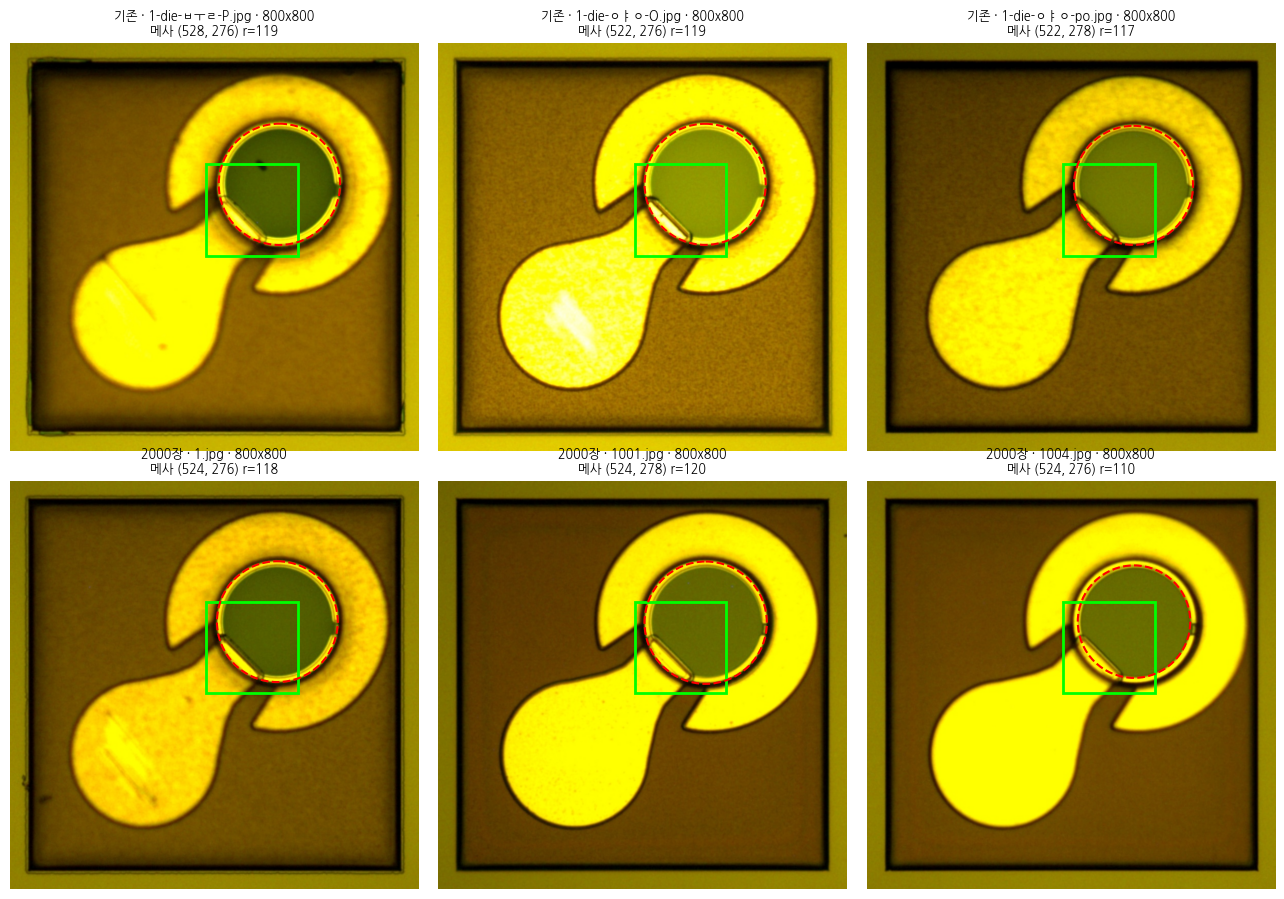

In [15]:
# @title ROI 정렬 확인
import matplotlib.patches as mpatches
import numpy as np
import cv2

ROI_BOX = (384, 236, 564, 416)
EXT_DIR = "/content/drive/MyDrive/260731"
ANSWER_CSV = "/content/drive/MyDrive/정답지_260731.csv"

def find_mesa(path):
    g = cv2.medianBlur(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2GRAY), 5)
    c = cv2.HoughCircles(g, cv2.HOUGH_GRADIENT, dp=1, minDist=120,
                         param1=120, param2=40, minRadius=95, maxRadius=155)
    if c is None:
        return None
    Y, X = np.ogrid[:g.shape[0], :g.shape[1]]
    best = None
    for x, y, r in c[0][:8]:
        m = (X - x) ** 2 + (Y - y) ** 2 < (0.7 * r) ** 2
        v = g[m].mean()
        if best is None or v < best[0]:
            best = (v, x, y, r)
    return best[1], best[2], best[3]

def show_roi(paths, tag, axrow):
    x0, y0, x1, y1 = ROI_BOX
    for ax, p in zip(axrow, paths):
        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                        fill=False, lw=2, color="lime"))
        m = find_mesa(p)
        sub = ""
        if m:
            cx, cy, r = m
            ax.add_patch(mpatches.Circle((cx, cy), r, fill=False, lw=1.5,
                                         ls="--", color="red"))
            sub = f"\n메사 ({cx:.0f}, {cy:.0f}) r={r:.0f}"
        ax.set_title(f"{tag} · {os.path.basename(p)} · {img.size[0]}x{img.size[1]}{sub}",
                     fontsize=9)
        ax.axis("off")
    for ax in axrow[len(paths):]:
        ax.axis("off")

def pick(root, n=3):
    if not os.path.isdir(root):
        print(f"폴더 없음: {root}")
        return []
    return sorted(p for p in glob.glob(os.path.join(root, "**", "*"), recursive=True)
                  if p.lower().endswith(IMG_EXTS))[:n]

inner, outer = pick(DATA_DIR), pick(EXT_DIR)
for p in inner + outer:
    print(f"  {os.path.basename(p):40s} {Image.open(p).size}")

print(f"\nROI {ROI_BOX}  크기 {ROI_BOX[2]-ROI_BOX[0]} x {ROI_BOX[3]-ROI_BOX[1]}")
print("기준 배치 메사 중심 (522, 277) r 116 — 새 배치가 여기서 크게 벗어나면 ROI 재산정 필요")

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
show_roi(inner, "기존", axes[0])
show_roi(outer, "2000장", axes[1])
plt.tight_layout()
plt.show()

In [16]:
# @title 메사 위치 검출
import json
import numpy as np
import cv2

MESA_JSON = "/content/drive/MyDrive/mesa_centers.json"
MESA_FALLBACK = (522.0, 277.0, 116.0)
OFFICIAL_DIRS = ["/content/drive/MyDrive/260731", "/content/drive/MyDrive/260721"]

def detect_mesa(path):
    g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if g is None:
        return None
    c = cv2.HoughCircles(cv2.medianBlur(g, 5), cv2.HOUGH_GRADIENT, dp=1,
                         minDist=120, param1=120, param2=40,
                         minRadius=95, maxRadius=155)
    if c is None:
        return None
    Y, X = np.ogrid[:g.shape[0], :g.shape[1]]
    best = None
    for x, y, r in c[0][:8]:
        m = (X - x) ** 2 + (Y - y) ** 2 < (0.7 * r) ** 2
        v = float(g[m].mean())
        if best is None or v < best[0]:
            best = (v, float(x), float(y), float(r))
    return best[1], best[2], best[3]

official_files = []
for d in OFFICIAL_DIRS:
    if os.path.isdir(d):
        official_files += [p for p in glob.glob(os.path.join(d, "**", "*"), recursive=True)
                           if p.lower().endswith(IMG_EXTS)]

MESA = {}
if os.path.exists(MESA_JSON):
    MESA = {k: tuple(v) for k, v in json.load(open(MESA_JSON)).items()}
    print(f"캐시 로드 {len(MESA)}장  ({MESA_JSON})")

todo = [p for p in target + official_files if os.path.basename(p) not in MESA]
if todo:
    print(f"검출 시작 {len(todo)}장 (학습 풀 {len(target)} + 정답지 배치 {len(official_files)})")
    fail = 0
    for i, p in enumerate(todo):
        v = detect_mesa(p)
        if v is None:
            fail += 1
            v = MESA_FALLBACK
        MESA[os.path.basename(p)] = v
        if (i + 1) % 300 == 0:
            print(f"  {i + 1}/{len(todo)}")
    json.dump({k: list(v) for k, v in MESA.items()}, open(MESA_JSON, "w"))
    print(f"검출 완료 | 실패 {fail}장은 기본값 사용 | 저장 {MESA_JSON}")

def mesa_of(path):
    return MESA.get(os.path.basename(path), MESA_FALLBACK)

def report_spread(paths, label):
    A = np.array([MESA[os.path.basename(p)] for p in paths if os.path.basename(p) in MESA])
    if len(A) == 0:
        print(f"{label}: 자료 없음")
        return
    print(f"\n[{label}]  {'항목':6s} {'중앙값':>8s} {'5%':>8s} {'95%':>8s} {'폭':>7s}")
    for i, nm in enumerate(["중심 x", "중심 y", "반지름"]):
        q = np.percentile(A[:, i], [5, 50, 95])
        print(f"{nm:6s} {q[1]:>8.1f} {q[0]:>8.1f} {q[2]:>8.1f} {q[2]-q[0]:>7.1f}")
    spread = max(np.percentile(A[:, 0], 95) - np.percentile(A[:, 0], 5),
                 np.percentile(A[:, 1], 95) - np.percentile(A[:, 1], 5))
    print("정렬 " + ("양호 — 고정 ROI도 안전" if spread < 20
                    else f"주의 — 중심이 {spread:.0f}px 흔들립니다. 배치가 섞였는지 확인하세요"))
    fb = sum(1 for p in paths if MESA.get(os.path.basename(p)) == MESA_FALLBACK)
    print(f"기본값(검출 실패) 사용 {fb}/{len(paths)}장")

report_spread(target, "학습 풀")
report_spread(official_files, "정답지 배치 (260731+260721)")

캐시 로드 5498장  (/content/drive/MyDrive/mesa_centers.json)

[학습 풀]  항목          중앙값       5%      95%       폭
중심 x      522.5    520.5    524.5     4.0
중심 y      277.5    275.5    279.5     4.0
반지름       116.6    105.1    128.5    23.4
정렬 양호 — 고정 ROI도 안전
기본값(검출 실패) 사용 23/4122장

[정답지 배치 (260731+260721)]  항목          중앙값       5%      95%       폭
중심 x      522.5    519.5    524.5     5.0
중심 y      277.5    275.5    279.5     4.0
반지름       116.0    104.8    128.6    23.8
정렬 양호 — 고정 ROI도 안전
기본값(검출 실패) 사용 0/1135장


In [17]:
# @title 패치 크기 및 이미지 로딩 유틸
import torchvision.transforms as T

PATCH = 128
STRIDE = PATCH // 2
eval_tf = T.ToTensor()

def load_padded(path, size=PATCH):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    if w < size or h < size:
        canvas = Image.new("RGB", (max(w, size), max(h, size)))
        canvas.paste(img, (0, 0))
        img = canvas
    return img

In [18]:
# @title MIL 데이터셋 (다중라벨 + ROI 샘플링)
import math
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from collections import Counter

LETTERS = USE
BIN_IDX = len(LETTERS)
ROI_C = (384, 236, 564, 416)
DIE_PAD = 48
K_RING, K_BOX, K_RAND = 3, 2, 7
RING_JITTER = 12
JIT_BRIGHT, JIT_CONTRAST = 0.25, 0.25
VAL_GOOD = 500
MIN_SPLIT = 5
MIN_REPORT = 5

rng = random.Random(42)
tr_items, va_items, te_items = [], [], []
for idx, paths in enumerate(cls_paths):
    ps = paths[:]
    rng.shuffle(ps)
    n = len(ps)
    if n < MIN_SPLIT:
        tr_items += [(p, idx) for p in ps]
        continue
    n_te = max(1, int(n * 0.2))
    n_va = max(1, int(n * 0.2))
    te_items += [(p, idx) for p in ps[:n_te]]
    va_items += [(p, idx) for p in ps[n_te:n_te + n_va]]
    tr_items += [(p, idx) for p in ps[n_te + n_va:]]
rng.shuffle(tr_items)

assert not ({p for p, _ in tr_items} & {p for p, _ in va_items + te_items}), "분할 누수"

def letter_vec(cls_idx):
    name = CLASS_NAMES[cls_idx]
    if name == "공식불량":
        return torch.tensor([0.0] * len(LETTERS) + [1.0])
    v = [1.0 if L in name else 0.0 for L in LETTERS]
    return torch.tensor(v + [1.0 if sum(v) > 0 else 0.0])

def die_bounds(w, h, pad=DIE_PAD):
    lo_x, lo_y = pad, pad
    hi_x, hi_y = w - pad - PATCH, h - pad - PATCH
    if hi_x < lo_x:
        lo_x, hi_x = 0, max(w - PATCH, 0)
    if hi_y < lo_y:
        lo_y, hi_y = 0, max(h - PATCH, 0)
    return lo_x, lo_y, hi_x, hi_y

def clamp_pos(x, y, w, h):
    lo_x, lo_y, hi_x, hi_y = die_bounds(w, h)
    return (int(min(max(x, lo_x), hi_x)), int(min(max(y, lo_y), hi_y)))

def pos_box(w, h, rng):
    x0, y0, x1, y1 = ROI_C
    return clamp_pos(rng.randint(x0, max(x0, x1 - PATCH)),
                     rng.randint(y0, max(y0, y1 - PATCH)), w, h)

def pos_ring(path, w, h, rng):
    cx, cy, r = mesa_of(path)
    t = rng.uniform(0, 2 * math.pi)
    rad = r + rng.uniform(-RING_JITTER, RING_JITTER)
    return clamp_pos(cx + rad * math.cos(t) - PATCH / 2,
                     cy + rad * math.sin(t) - PATCH / 2, w, h)

def pos_rand(w, h, rng):
    lo_x, lo_y, hi_x, hi_y = die_bounds(w, h)
    return rng.randint(lo_x, hi_x), rng.randint(lo_y, hi_y)

def jitter_tone(x, rng):
    c = 1.0 + rng.uniform(-JIT_CONTRAST, JIT_CONTRAST)
    b = rng.uniform(-JIT_BRIGHT, JIT_BRIGHT)
    return torch.clamp((x - 0.5) * c + 0.5 + b, 0.0, 1.0)

class MILDataset(Dataset):
    def __init__(self, items, augment=True):
        self.items = items
        self.augment = augment
        self.epoch = 0
    def set_epoch(self, ep):
        self.epoch = ep
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        path, cls = self.items[i]
        rng = random.Random((self.epoch * 100003 + i) & 0xffffffff)
        img = load_padded(path)
        w, h = img.size
        full = eval_tf(img)
        if self.augment:
            full = jitter_tone(full, rng)
        pos = [pos_ring(path, w, h, rng) for _ in range(K_RING)] + \
              [pos_box(w, h, rng) for _ in range(K_BOX)] + \
              [pos_rand(w, h, rng) for _ in range(K_RAND)]
        xs = []
        for x, y in pos:
            p = full[:, y:y + PATCH, x:x + PATCH]
            if rng.random() < 0.5:
                p = torch.flip(p, [2])
            if rng.random() < 0.5:
                p = torch.flip(p, [1])
            xs.append(p)
        return torch.stack(xs), letter_vec(cls)

def make_eval_subset(items, n_good=VAL_GOOD, seed=0):
    good = [it for it in items if CLASS_NAMES[it[1]] == "양품"]
    bad = [it for it in items if CLASS_NAMES[it[1]] != "양품"]
    g = random.Random(seed)
    picked = g.sample(good, min(n_good, len(good)))
    return bad + picked, len(good) / max(len(picked), 1)

tr_ml = MILDataset(tr_items)
va_fast, GOOD_SCALE = make_eval_subset(va_items)

train_letter = torch.stack([letter_vec(y) for _, y in tr_items])
n_bad = int(train_letter[:, BIN_IDX].sum())
n_good = len(tr_items) - n_bad
w_die = [1.0 / n_good if train_letter[i, BIN_IDX] == 0 else 1.0 / n_bad
         for i in range(len(tr_items))]
cnt = train_letter.sum(0)
pos_weight = (n_bad / cnt.clamp(min=1)).clamp(max=5.0)
pos_weight[BIN_IDX] = 1.0

va_bad = sum(1 for _, y in va_items if CLASS_NAMES[y] != "양품")
te_bad = sum(1 for _, y in te_items if CLASS_NAMES[y] != "양품")
_lo_x, _lo_y, _hi_x, _hi_y = die_bounds(800, 800)
print(f"지표 {LETTERS} | bag {K_RING + K_BOX + K_RAND}장 = "
      f"링 {K_RING} + 박스 {K_BOX} + 무작위 {K_RAND}")
print(f"다이 영역 제한 pad {DIE_PAD}px | patch 좌상단 범위 "
      f"x {_lo_x}~{_hi_x} · y {_lo_y}~{_hi_y}")
print(f"증강: 좌우/상하 반전 + 밝기 ±{JIT_BRIGHT} · 대비 ±{JIT_CONTRAST}")
print(f"train {len(tr_items):>4d}  (양품 {n_good} / 불량 {n_bad})")
print(f"val   {len(va_items):>4d}  (불량 {va_bad})   test {len(te_items):>4d}  (불량 {te_bad})")
print(f"빠른 검증 {len(va_fast)}장 | FP 보정계수 {GOOD_SCALE:.2f}")
print(f"train 지표별 양성 {dict(zip(list(LETTERS) + ['불량'], cnt.int().tolist()))}")
print(f"pos_weight        {dict(zip(list(LETTERS) + ['불량'], [round(v, 1) for v in pos_weight.tolist()]))}")
print(f"val 구성  {dict(Counter(CLASS_NAMES[y] for _, y in va_items))}")
print(f"test 구성 {dict(Counter(CLASS_NAMES[y] for _, y in te_items))}")

지표 PS | bag 12장 = 링 3 + 박스 2 + 무작위 7
다이 영역 제한 pad 48px | patch 좌상단 범위 x 48~624 · y 48~624
증강: 좌우/상하 반전 + 밝기 ±0.25 · 대비 ±0.25
train 1440  (양품 1243 / 불량 197)
val    475  (불량 62)   test  475  (불량 62)
빠른 검증 475장 | FP 보정계수 1.00
train 지표별 양성 {'P': 124, 'S': 31, '불량': 197}
pos_weight        {'P': 1.6, 'S': 5.0, '불량': 1.0}
val 구성  {'양품': 413, 'P': 33, 'S': 2, 'PS': 6, '공식불량': 21}
test 구성 {'양품': 413, 'P': 33, 'S': 2, 'PS': 6, '공식불량': 21}


In [19]:
# @title MIL 모델
def build_mil_cnn(channels=(16, 32, 64), n_out=len(LETTERS) + 1, pool=4):
    layers, c_in = [], 3
    for c in channels:
        layers += [nn.Conv2d(c_in, c, 3, padding=1, bias=False),
                   nn.BatchNorm2d(c), nn.ReLU(inplace=True), nn.MaxPool2d(2)]
        c_in = c
    layers += [nn.AdaptiveAvgPool2d(pool), nn.Flatten(),
               nn.Linear(c_in * pool * pool, n_out)]
    return nn.Sequential(*layers)

print(f"{'구성':32s} {'FC 입력':>8s} {'params':>10s}")
for ch, pl in (((8, 16, 16), 16), ((8, 16, 16), 4), ((16, 32, 64), 4)):
    m = build_mil_cnn(ch, pool=pl)
    print(f"channels={str(ch):16s} pool={pl:<3d} {m[-1].in_features:>8d} "
          f"{sum(p.numel() for p in m.parameters()):>10,}")

model_ml = build_mil_cnn().to(DEVICE)
print()
print(model_ml)
print(f"\nFC 입력 {model_ml[-1].in_features} | 출력 {model_ml[-1].out_features}개 "
      f"({'/'.join(LETTERS)} + 불량) | params {sum(p.numel() for p in model_ml.parameters()):,}")

구성                                  FC 입력     params
channels=(8, 16, 16)      pool=16      4096     16,043
channels=(8, 16, 16)      pool=4        256      4,523
channels=(16, 32, 64)     pool=4       1024     26,771

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Max

In [20]:
# @title 사전학습 백본 MIL 모델
import torchvision.models as tvm

FREEZE_UNTIL = 5

class ImageNetNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer("m", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("s", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        return (x - self.m) / self.s

class FrozenBNSequential(nn.Sequential):
    def train(self, mode=True):
        super().train(mode)
        for m in self.modules():
            if isinstance(m, nn.BatchNorm2d) and \
                    not any(p.requires_grad for p in m.parameters()):
                m.eval()
        return self

def build_mil_resnet(n_out=len(LETTERS) + 1, freeze_until=FREEZE_UNTIL):
    net = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
    net.fc = nn.Linear(net.fc.in_features, n_out)
    for i, (_, mod) in enumerate(net.named_children()):
        if i < freeze_until:
            for prm in mod.parameters():
                prm.requires_grad = False
    return FrozenBNSequential(ImageNetNorm(), net)

model_ml = build_mil_resnet().to(DEVICE)
tot = sum(p.numel() for p in model_ml.parameters())
trn = sum(p.numel() for p in model_ml.parameters() if p.requires_grad)
frozen_bn = sum(1 for m in model_ml.modules()
                if isinstance(m, nn.BatchNorm2d)
                and not any(p.requires_grad for p in m.parameters()))
print(f"ResNet18 (ImageNet 사전학습) | 전체 {tot:,} | 학습 {trn:,} | 동결 {tot - trn:,}")
print(f"동결 BatchNorm {frozen_bn}개 — 학습 중에도 running stats 갱신 안 함")
print(f"입력 {PATCH}x{PATCH} · 출력 {len(LETTERS) + 1}개 ({'/'.join(LETTERS)} + 불량)")
if not torch.cuda.is_available():
    print("경고 — CPU에서는 사실상 학습 불가입니다")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


ResNet18 (ImageNet 사전학습) | 전체 11,178,051 | 학습 11,020,547 | 동결 157,504
동결 BatchNorm 5개 — 학습 중에도 running stats 갱신 안 함
입력 128x128 · 출력 3개 (P/S + 불량)


In [21]:
# @title MIL 추론 / 지표
import math

KMAX = 16
N_RING_EVAL = 16
TTA_EVAL = True
FLIPS = ((), (3,), (2,), (2, 3))

def clamp_eval(x, y, w, h):
    lo_x, lo_y, hi_x, hi_y = die_bounds(w, h)
    return (int(min(max(x, lo_x), hi_x)), int(min(max(y, lo_y), hi_y)))

def die_grid(w, h, stride=STRIDE):
    lo_x, lo_y, hi_x, hi_y = die_bounds(w, h)
    xs = list(range(lo_x, hi_x + 1, stride))
    ys = list(range(lo_y, hi_y + 1, stride))
    if xs[-1] != hi_x:
        xs.append(hi_x)
    if ys[-1] != hi_y:
        ys.append(hi_y)
    return [(x, y) for y in ys for x in xs]

def box_positions(w, h):
    x0, y0, x1, y1 = ROI_C
    return [clamp_eval(x0, y0, w, h), clamp_eval(x1 - PATCH, y0, w, h),
            clamp_eval(x0, y1 - PATCH, w, h), clamp_eval(x1 - PATCH, y1 - PATCH, w, h)]

def ring_positions(path, w, h, n=N_RING_EVAL):
    cx, cy, r = mesa_of(path)
    return [clamp_eval(cx + r * math.cos(2 * math.pi * i / n) - PATCH / 2,
                       cy + r * math.sin(2 * math.pi * i / n) - PATCH / 2, w, h)
            for i in range(n)]

def all_positions(path, w, h, coarse=False):
    grid = die_grid(w, h, stride=PATCH if coarse else STRIDE)
    return grid + box_positions(w, h) + ring_positions(path, w, h)

def patch_stack(path, coarse=False):
    img = load_padded(path)
    w, h = img.size
    full = eval_tf(img)
    return torch.stack([full[:, y:y + PATCH, x:x + PATCH]
                        for x, y in all_positions(path, w, h, coarse)])

@torch.no_grad()
def _forward(model, xs, device, batch):
    outs = []
    for i in range(0, len(xs), batch):
        outs.append(torch.sigmoid(model(xs[i:i + batch].to(device))).cpu())
    return torch.cat(outs)

@torch.no_grad()
def patch_probs(model, path, device, batch=256, coarse=False, tta=False):
    xs = patch_stack(path, coarse)
    variants = FLIPS if tta else ((),)
    acc = None
    for fl in variants:
        z = torch.flip(xs, list(fl)) if fl else xs
        o = _forward(model, z, device, batch)
        acc = o if acc is None else acc + o
    return acc / len(variants)

@torch.no_grad()
def die_letter_scores(model, path, device, batch=256, coarse=False, tta=False):
    return patch_probs(model, path, device, batch, coarse, tta).max(0).values

@torch.no_grad()
def die_topvals(model, path, device, kmax=KMAX, batch=256, tta=None):
    use = TTA_EVAL if tta is None else tta
    o = patch_probs(model, path, device, batch, coarse=False, tta=use)
    return o.topk(min(kmax, len(o)), 0).values

@torch.no_grad()
def collect_val(model, items, device):
    model.eval()
    S = torch.stack([die_letter_scores(model, p, device, coarse=True) for p, _ in items])
    Y = torch.stack([letter_vec(g) for _, g in items])
    return S, Y

def binary_metrics(S, Y, thr, good_scale=1.0):
    score, is_bad = S[:, BIN_IDX], Y[:, BIN_IDX] > 0
    pred = score >= thr
    tp = int((pred & is_bad).sum())
    fn = int((~pred & is_bad).sum())
    fp = int((pred & ~is_bad).sum()) * good_scale
    tn = int((~pred & ~is_bad).sum()) * good_scale
    r = tp / max(tp + fn, 1)
    p = tp / max(tp + fp, 1e-9)
    return r, p, 2 * r * p / max(r + p, 1e-9), (tp, fp, fn, tn)

def plateau_mid(cand, scores):
    best = max(scores)
    runs, cur = [], []
    for i, v in enumerate(scores):
        if v >= best - 1e-12:
            cur.append(i)
        elif cur:
            runs.append(cur)
            cur = []
    if cur:
        runs.append(cur)
    r = max(runs, key=len)
    return (cand[r[0]] + cand[r[-1]]) / 2

def best_thr(S, Y, good_scale=1.0):
    cand = sorted(set(S[:, BIN_IDX].tolist()))
    return plateau_mid(cand, [binary_metrics(S, Y, t, good_scale)[2] for t in cand])

def thr_at_recall(S, Y, target, good_scale=1.0):
    cand = sorted(set(S[:, BIN_IDX].tolist()))
    ok = [t for t in cand if binary_metrics(S, Y, t, good_scale)[0] >= target]
    return max(ok) if ok else cand[0]

def average_precision(S, Y, good_scale=1.0):
    is_bad = Y[:, BIN_IDX] > 0
    tp = fp = ap = 0.0
    for i in torch.argsort(S[:, BIN_IDX], descending=True).tolist():
        if is_bad[i]:
            tp += 1
            ap += tp / (tp + fp)
        else:
            fp += good_scale
    return ap / max(int(is_bad.sum()), 1)

def best_letter_thr(S, Y, min_pos=MIN_REPORT):
    is_bad = Y[:, BIN_IDX] > 0
    Sb, Yb = S[is_bad], Y[is_bad]
    thrs = {}
    for j, L in enumerate(LETTERS):
        gt = Yb[:, j] > 0
        if int(gt.sum()) < min_pos:
            thrs[L] = None
            continue
        cand = sorted(set(Sb[:, j].tolist()))
        f1s = []
        for t in cand:
            pr = Sb[:, j] >= t
            f1s.append(2 * int((gt & pr).sum()) / max(int(pr.sum()) + int(gt.sum()), 1))
        thrs[L] = plateau_mid(cand, f1s)
    return thrs

def _pct(vals, lo=0.025, hi=0.975):
    v = sorted(vals)
    return v[int(lo * len(v))], v[min(int(hi * len(v)), len(v) - 1)]

def bootstrap_ci(S, Y, thr, good_scale=1.0, n=1000, seed=0):
    g = torch.Generator().manual_seed(seed)
    rs, ps = [], []
    for _ in range(n):
        idx = torch.randint(0, len(S), (len(S),), generator=g)
        r, p, _, _ = binary_metrics(S[idx], Y[idx], thr, good_scale)
        rs.append(r)
        ps.append(p)
    return _pct(rs), _pct(ps)

_ng = len(die_grid(800, 800))
print("추론 격자 %d칸 + 박스 4 + 링 %d = %d칸 (배경 제외)"
      % (_ng, N_RING_EVAL, _ng + 4 + N_RING_EVAL))
print("TTA %s | 학습 중 검증은 TTA 미사용 (속도 유지)"
      % ("사용 (반전 4방향 평균)" if TTA_EVAL else "미사용"))

추론 격자 100칸 + 박스 4 + 링 16 = 120칸 (배경 제외)
TTA 사용 (반전 4방향 평균) | 학습 중 검증은 TTA 미사용 (속도 유지)


In [22]:
# @title MIL 학습
import math, json, datetime

DRIVE_DIR = "/content/drive/MyDrive"
DRIVE_CKPT = os.path.join(DRIVE_DIR, "best_mil.pth")
DRIVE_LAST = os.path.join(DRIVE_DIR, "last_mil.pt")
DRIVE_PROG = os.path.join(DRIVE_DIR, "mil_progress.json")
LOCAL_CKPT = "best_mil.pth"
LOCAL_LAST = "last_mil.pt"
LOCAL_PROG = "mil_progress.json"
LR = 3e-4
BATCH = 8
EPOCHS = 120
RESUME = False
LAST_EVERY = 5

def drive_alive():
    try:
        return os.path.isdir(DRIVE_DIR) and os.access(DRIVE_DIR, os.W_OK)
    except OSError:
        return False

def safe_copy(src, dst):
    if not drive_alive():
        return False
    try:
        shutil.copy(src, dst)
        return True
    except Exception as e:
        print("  드라이브 복사 실패 %s: %s" % (os.path.basename(dst), e), flush=True)
        return False

def read_progress():
    for p in (LOCAL_PROG, DRIVE_PROG):
        if os.path.exists(p):
            try:
                return json.load(open(p, encoding="utf-8"))
            except Exception:
                pass
    return None

def show_progress():
    pg = read_progress()
    if not pg:
        print("이전 학습 기록 없음 — 처음부터 시작합니다", flush=True)
        return
    print("이전 학습 기록: %d epoch 완료 | best AP3 %.3f (epoch %s) | 저장 %s"
          % (pg["epoch"], pg["best"], pg.get("best_epoch", "?"), pg.get("saved_at", "?")),
          flush=True)
    full = os.path.exists(LOCAL_LAST) or os.path.exists(DRIVE_LAST)
    has_w = os.path.exists(LOCAL_CKPT) or os.path.exists(DRIVE_CKPT)
    print("  재개 파일 %s | best 가중치 %s"
          % ("있음 (옵티마이저 포함)" if full else "없음", "있음" if has_w else "없음"),
          flush=True)

def train_mil(model, ds, items_val, device, epochs=EPOCHS, lr=LR, batch_size=BATCH,
              patience=25, topk=1, good_scale=1.0, bags_per_bad=6,
              warmup_ep=3, clip=5.0, save=LOCAL_CKPT):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    def lr_at(ep):
        if ep < warmup_ep:
            return (ep + 1) / warmup_ep
        t = (ep - warmup_ep) / max(epochs - warmup_ep, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    sch = torch.optim.lr_scheduler.LambdaLR(opt, lr_at)
    history, aps = [], []
    best, best_epoch, no_imp, start_ep, drive_fail = -1.0, 0, 0, 1, 0

    want = (RESUME is True) or (RESUME == "auto" and read_progress() is not None)
    if want:
        full = next((p for p in (LOCAL_LAST, DRIVE_LAST) if os.path.exists(p)), None)
        if full:
            ck = torch.load(full, map_location=device)
            model.load_state_dict(ck["model"])
            opt.load_state_dict(ck["opt"])
            sch.load_state_dict(ck["sch"])
            history, aps = ck["history"], ck["aps"]
            best, best_epoch = ck["best"], ck.get("best_epoch", 0)
            no_imp, start_ep = ck["no_imp"], ck["epoch"] + 1
            print("재개 (옵티마이저 포함) — %d epoch 부터" % start_ep, flush=True)
        else:
            pg = read_progress()
            wpath = next((p for p in (LOCAL_CKPT, DRIVE_CKPT) if os.path.exists(p)), None)
            if pg and wpath:
                model.load_state_dict(torch.load(wpath, map_location=device))
                history, aps = pg["history"], pg["aps"]
                best, best_epoch = pg["best"], pg.get("best_epoch", 0)
                no_imp, start_ep = pg["no_imp"], pg["epoch"] + 1
                print("재개 (best 가중치만, 옵티마이저 초기화) — %d epoch 부터" % start_ep,
                      flush=True)
            else:
                print("재개 자료 불충분 — 처음부터 학습합니다", flush=True)
    else:
        print("처음부터 학습합니다", flush=True)

    if start_ep > epochs:
        print("이미 %d epoch 까지 끝났습니다. 더 돌리려면 EPOCHS 를 늘리세요"
              % (start_ep - 1), flush=True)
        return history

    def dump_progress(ep):
        pg = {"epoch": ep, "best": best, "best_epoch": best_epoch, "no_imp": no_imp,
              "history": history, "aps": aps, "epochs_target": epochs,
              "lr": lr, "batch": batch_size,
              "saved_at": datetime.datetime.now().isoformat(timespec="seconds")}
        json.dump(pg, open(LOCAL_PROG, "w", encoding="utf-8"), ensure_ascii=False)
        safe_copy(LOCAL_PROG, DRIVE_PROG)

    def dump_full(ep, to_drive):
        torch.save({"model": model.state_dict(), "opt": opt.state_dict(),
                    "sch": sch.state_dict(), "history": history, "aps": aps,
                    "best": best, "best_epoch": best_epoch,
                    "no_imp": no_imp, "epoch": ep}, LOCAL_LAST)
        if to_drive:
            safe_copy(LOCAL_LAST, DRIVE_LAST)

    ep = start_ep - 1
    try:
        for ep in range(start_ep, epochs + 1):
            ds.set_epoch(ep)
            sampler = WeightedRandomSampler(w_die, num_samples=bags_per_bad * n_bad,
                                            replacement=True,
                                            generator=torch.Generator().manual_seed(ep))
            dl = DataLoader(ds, batch_size=batch_size, sampler=sampler, num_workers=2)
            model.train()
            tot = seen = 0
            for x, y in dl:
                B, K, C, H, W = x.shape
                x, y = x.to(device), y.to(device)
                out = model(x.view(B * K, C, H, W)).view(B, K, -1)
                logit = out.topk(min(topk, K), dim=1).values.mean(1)
                loss = crit(logit, y)
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
                opt.step()
                tot += loss.item() * B
                seen += B
            sch.step()
            Sv, Yv = collect_val(model, items_val, device)
            thr = best_thr(Sv, Yv, good_scale)
            rc, pc, f1, _ = binary_metrics(Sv, Yv, thr, good_scale)
            apv = average_precision(Sv, Yv, good_scale)
            aps.append(apv)
            sm = sum(aps[-3:]) / len(aps[-3:])
            history.append((tot / seen, rc, pc, f1, thr, apv))
            mark = ""
            if sm > best:
                best, best_epoch, no_imp, mark = sm, ep, 0, " *"
                torch.save(model.state_dict(), save)
                if not safe_copy(save, DRIVE_CKPT):
                    drive_fail += 1
                    mark = " * (로컬만)"
            else:
                no_imp += 1
            print("epoch %3d/%d | loss %.4f | thr %.3f | recall %.3f | precision %.3f "
                  "| F1 %.3f | AP %.3f | AP3 %.3f%s"
                  % (ep, epochs, tot / seen, thr, rc, pc, f1, apv, sm, mark), flush=True)
            dump_progress(ep)
            dump_full(ep, to_drive=(ep % LAST_EVERY == 0))
            if no_imp >= patience:
                print("조기 종료 (%d epoch 동안 개선 없음)" % patience, flush=True)
                break
    except KeyboardInterrupt:
        print("\n중단됨 — %d epoch 까지 저장되어 있습니다" % ep, flush=True)
    except Exception as e:
        print("\n학습 중 오류: %s" % e, flush=True)
        print("%d epoch 까지의 기록과 가중치는 저장되어 있습니다" % ep, flush=True)

    dump_progress(ep)
    dump_full(ep, to_drive=True)
    safe_copy(save, DRIVE_CKPT)
    if drive_fail:
        print("드라이브 저장이 %d번 실패했습니다 — 마운트 확인 필요" % drive_fail, flush=True)
    return history

print("드라이브 쓰기 가능: %s" % drive_alive())
show_progress()
print("학습 시작 | lr %s | batch %d | 최대 %d epoch | 파라미터 %s"
      % (LR, BATCH, EPOCHS, format(sum(p.numel() for p in model_ml.parameters()), ",")))
history_ml = train_mil(model_ml, tr_ml, va_fast, DEVICE, good_scale=GOOD_SCALE)
print("학습 종료 | %d epoch 기록" % len(history_ml))
print("  best 가중치 %s" % DRIVE_CKPT)
print("  재개 파일   %s" % DRIVE_LAST)
print("  진행 기록   %s" % DRIVE_PROG)

드라이브 쓰기 가능: True
이전 학습 기록: 45 epoch 완료 | best AP3 0.728 (epoch 20) | 저장 2026-09-09T15:05:11
  재개 파일 있음 (옵티마이저 포함) | best 가중치 있음
학습 시작 | lr 0.0003 | batch 8 | 최대 120 epoch | 파라미터 11,178,051
처음부터 학습합니다
epoch   1/120 | loss 0.5051 | thr 0.715 | recall 0.403 | precision 0.714 | F1 0.515 | AP 0.458 | AP3 0.458 *
epoch   2/120 | loss 0.5459 | thr 0.925 | recall 0.387 | precision 0.828 | F1 0.527 | AP 0.455 | AP3 0.457
epoch   3/120 | loss 0.5722 | thr 0.958 | recall 0.371 | precision 0.920 | F1 0.529 | AP 0.532 | AP3 0.482 *
epoch   4/120 | loss 0.5504 | thr 0.861 | recall 0.516 | precision 0.681 | F1 0.587 | AP 0.652 | AP3 0.546 *
epoch   5/120 | loss 0.5286 | thr 0.728 | recall 0.484 | precision 0.714 | F1 0.577 | AP 0.600 | AP3 0.595 *
epoch   6/120 | loss 0.4961 | thr 0.859 | recall 0.565 | precision 0.700 | F1 0.625 | AP 0.606 | AP3 0.619 *
epoch   7/120 | loss 0.5315 | thr 0.844 | recall 0.548 | precision 0.708 | F1 0.618 | AP 0.608 | AP3 0.605
epoch   8/120 | loss 0.4743 | thr 0.971 |

In [23]:
# @title 앙상블 학습 (seed 3개)
import random, time, hashlib
import numpy as np

SEEDS = [0, 1, 2]
ENS_EPOCHS = 60
ENS_PATIENCE = 15

def data_fingerprint():
    key = "|".join(sorted(p for p, _ in tr_items)) + "::%d::%d::%d" % (
        len(va_items), len(te_items), len(LETTERS))
    return hashlib.md5(key.encode()).hexdigest()

def read_fp(path):
    return open(path, encoding="utf-8").read().strip() if os.path.exists(path) else None

def sync_from_drive(pairs):
    for lp, dp in pairs:
        if not os.path.exists(lp) and os.path.exists(dp):
            shutil.copy(dp, lp)

def remove_if_exists(path):
    if os.path.exists(path):
        os.remove(path)

FP_NOW = data_fingerprint()

_bk = (RESUME, DRIVE_CKPT, LOCAL_LAST, DRIVE_LAST, LOCAL_PROG, DRIVE_PROG)
ENS_PATHS = []
for s in SEEDS:
    tag = "ens%d" % s
    lp = "%s.pth" % tag
    dp = "/content/drive/MyDrive/%s.pth" % tag
    lp_fp = "%s_fp.txt" % tag
    dp_fp = "/content/drive/MyDrive/%s_fp.txt" % tag
    lp_last = "%s_last.pt" % tag
    dp_last = "/content/drive/MyDrive/%s_last.pt" % tag
    lp_prog = "%s_prog.json" % tag
    dp_prog = "/content/drive/MyDrive/%s_prog.json" % tag
    lp_pfp = "%s_pfp.txt" % tag
    dp_pfp = "/content/drive/MyDrive/%s_pfp.txt" % tag

    sync_from_drive([(lp, dp), (lp_fp, dp_fp), (lp_last, dp_last),
                      (lp_prog, dp_prog), (lp_pfp, dp_pfp)])

    cached_fp = read_fp(lp_fp)
    ok_shape = False
    if os.path.exists(lp) and cached_fp == FP_NOW:
        try:
            ck = torch.load(lp, map_location="cpu")
            w = ck.get("1.fc.weight", ck.get("fc.weight"))
            ok_shape = w is None or w.shape[0] == len(LETTERS) + 1
        except Exception:
            ok_shape = False
    if os.path.exists(lp) and cached_fp == FP_NOW and ok_shape:
        print("seed %d 이미 학습됨 (현재 데이터와 일치) — 건너뜀 (%s)" % (s, lp), flush=True)
        ENS_PATHS.append(lp)
        continue

    if os.path.exists(lp):
        print("seed %d 기존 완료 가중치가 다르거나 모양이 안 맞음 — 재학습" % s, flush=True)

    partial_fp = read_fp(lp_pfp)
    has_partial = os.path.exists(lp_last) or os.path.exists(lp_prog)
    can_resume = has_partial and partial_fp == FP_NOW
    if has_partial and not can_resume:
        print("seed %d 중간 저장이 현재 데이터와 다름 — 중간 기록 삭제 후 처음부터" % s, flush=True)
        remove_if_exists(lp_last); remove_if_exists(dp_last)
        remove_if_exists(lp_prog); remove_if_exists(dp_prog)

    RESUME = "auto" if can_resume else False
    DRIVE_CKPT = dp
    LOCAL_LAST = lp_last
    DRIVE_LAST = dp_last
    LOCAL_PROG = lp_prog
    DRIVE_PROG = dp_prog

    open(lp_pfp, "w", encoding="utf-8").write(FP_NOW)
    safe_copy(lp_pfp, dp_pfp)

    torch.manual_seed(s)
    random.seed(s)
    np.random.seed(s)
    m = build_mil_resnet().to(DEVICE)
    ds = MILDataset(tr_items)
    _base = ds.set_epoch
    ds.set_epoch = lambda ep, _b=_base, _o=s * 977: _b(ep + _o)
    print("=" * 62, flush=True)
    print("seed %d 학습 시작 (%s, 최대 %d epoch)"
          % (s, "재개" if can_resume else "새로 시작", ENS_EPOCHS), flush=True)
    t0 = time.time()
    train_mil(m, ds, va_fast, DEVICE, epochs=ENS_EPOCHS, patience=ENS_PATIENCE,
              good_scale=GOOD_SCALE, save=lp)
    print("seed %d 완료 — %.0f분" % (s, (time.time() - t0) / 60), flush=True)
    open(lp_fp, "w", encoding="utf-8").write(FP_NOW)
    safe_copy(lp_fp, dp_fp)
    ENS_PATHS.append(lp)

RESUME, DRIVE_CKPT, LOCAL_LAST, DRIVE_LAST, LOCAL_PROG, DRIVE_PROG = _bk
print("=" * 62)
print("앙상블 가중치 %d개: %s" % (len(ENS_PATHS), ENS_PATHS))

seed 0 이미 학습됨 (현재 데이터와 일치) — 건너뜀 (ens0.pth)
seed 1 이미 학습됨 (현재 데이터와 일치) — 건너뜀 (ens1.pth)
seed 2 기존 완료 가중치가 다르거나 모양이 안 맞음 — 재학습
seed 2 학습 시작 (재개, 최대 60 epoch)
재개 (옵티마이저 포함) — 36 epoch 부터
epoch  36/60 | loss 0.3588 | thr 0.974 | recall 0.645 | precision 0.741 | F1 0.690 | AP 0.662 | AP3 0.660
epoch  37/60 | loss 0.3530 | thr 0.987 | recall 0.629 | precision 0.736 | F1 0.678 | AP 0.691 | AP3 0.665
epoch  38/60 | loss 0.3772 | thr 0.969 | recall 0.661 | precision 0.707 | F1 0.683 | AP 0.684 | AP3 0.679
epoch  39/60 | loss 0.3502 | thr 0.973 | recall 0.694 | precision 0.694 | F1 0.694 | AP 0.688 | AP3 0.688
epoch  40/60 | loss 0.3688 | thr 0.962 | recall 0.677 | precision 0.712 | F1 0.694 | AP 0.693 | AP3 0.689
epoch  41/60 | loss 0.3328 | thr 0.947 | recall 0.661 | precision 0.732 | F1 0.695 | AP 0.691 | AP3 0.691
epoch  42/60 | loss 0.3696 | thr 0.938 | recall 0.661 | precision 0.759 | F1 0.707 | AP 0.709 | AP3 0.698
epoch  43/60 | loss 0.3993 | thr 0.824 | recall 0.694 | precision 0.672 |

In [24]:
# @title 앙상블 평가
import numpy as np

K_LIST_E = [1, 2, 4, 8, 16]
FORCE_RECALC = False

def acc_at2(sc, lab, t):
    pr = sc >= t
    return float(((pr & lab) | (~pr & ~lab)).float().mean())

def pick_t(sc, lab):
    cand = sorted(set(sc.tolist()))
    return plateau_mid(cand, [acc_at2(sc, lab, t) for t in cand])

def ap_at(sc, lab):
    s = sc.detach().cpu().numpy()
    y = lab.detach().cpu().numpy()
    tp = fp = ap = 0.0
    for i in np.argsort(-s):
        if y[i]:
            tp += 1
            ap += tp / (tp + fp)
        else:
            fp += 1
    return ap / max(int(y.sum()), 1)

Yv = torch.stack([letter_vec(g) for _, g in va_items])
Yt = torch.stack([letter_vec(g) for _, g in te_items])
lab_v = Yv[:, BIN_IDX] > 0
lab_t = Yt[:, BIN_IDX] > 0

_ens_key_now = tuple((w, os.path.getmtime(w)) for w in ENS_PATHS)
_have = ("Tt_all" in globals() and "Tv_all" in globals() and "_ens_score_key" in globals()
         and _ens_score_key == _ens_key_now
         and len(Tt_all) == len(ENS_PATHS) and len(Tv_all) == len(ENS_PATHS)
         and all(len(t) == len(va_items) for t in Tv_all)
         and all(len(t) == len(te_items) for t in Tt_all))
if _have and not FORCE_RECALC:
    print("이미 계산된 점수 재사용 (%d개 모델) — 다시 계산하려면 FORCE_RECALC = True"
          % len(ENS_PATHS))
else:
    Tv_all, Tt_all = [], []
    for w in ENS_PATHS:
        m = build_mil_resnet().to(DEVICE)
        m.load_state_dict(torch.load(w, map_location=DEVICE))
        m.eval()
        print("평가 중 %s" % w, flush=True)
        Tv_all.append(torch.stack([die_topvals(m, p, DEVICE) for p, _ in va_items]))
        Tt_all.append(torch.stack([die_topvals(m, p, DEVICE) for p, _ in te_items]))
        del m
        torch.cuda.empty_cache()
    _ens_score_key = _ens_key_now

def report(tag, Sv, St):
    t = pick_t(Sv, lab_v)
    pr = St >= t
    tp_ = int((pr & lab_t).sum())
    fn_ = int((~pr & lab_t).sum())
    fp_ = int((pr & ~lab_t).sum())
    return (tag, acc_at2(Sv, lab_v, t), float(t), acc_at2(St, lab_t, t),
            ap_at(St, lab_t), tp_ / max(tp_ + fn_, 1), tp_ / max(tp_ + fp_, 1),
            fn_, fp_)

rows = []
for k in K_LIST_E:
    for j in range(len(ENS_PATHS)):
        rows.append(report("seed%d k=%d" % (SEEDS[j], k),
                           Tv_all[j][:, :k].mean(1)[:, BIN_IDX],
                           Tt_all[j][:, :k].mean(1)[:, BIN_IDX]))
    sv = torch.stack([T[:, :k].mean(1)[:, BIN_IDX] for T in Tv_all]).mean(0)
    st = torch.stack([T[:, :k].mean(1)[:, BIN_IDX] for T in Tt_all]).mean(0)
    rows.append(report("앙상블 k=%d" % k, sv, st))

print("")
print("=" * 94)
print(" %-14s %9s %8s %10s %9s %8s %10s %6s %6s"
      % ("", "val정확도", "thr", "test정확도", "test AP", "recall", "precision",
         "미검출", "과검"))
ens_rows = [v for v in rows if v[0].startswith("앙상블")]
best = max(ens_rows, key=lambda v: v[1])
for v in rows:
    mark = "  <- val 기준 선택" if v is best else ""
    sep = ">" if v[0].startswith("앙상블") else " "
    print("%s%-14s %9.3f %8.3f %10.3f %9.3f %8.3f %10.3f %6d %6d%s"
          % (sep, v[0], v[1], v[2], v[3], v[4], v[5], v[6], v[7], v[8], mark))
print("-" * 94)
solo = [v for v in rows if not v[0].startswith("앙상블")]
best_solo = max(solo, key=lambda v: v[1])
print("단독 최고 (val 기준)  %s -> test %.3f / AP %.3f / 미검출 %d"
      % (best_solo[0], best_solo[3], best_solo[4], best_solo[7]))
print("앙상블 선택          %s -> test %.3f / AP %.3f / 미검출 %d  (%+.3f)"
      % (best[0], best[3], best[4], best[7], best[3] - best_solo[3]))
need = int(np.ceil(0.9 * len(te_items))) - int(round(best[3] * len(te_items)))
print("정확도 0.9까지 %d장" % max(need, 0))
print("=" * 94)

평가 중 ens0.pth
평가 중 ens1.pth
평가 중 ens2.pth

                   val정확도      thr    test정확도   test AP   recall  precision    미검출     과검
 seed0 k=1          0.924    0.826      0.931     0.745    0.581      0.837     26      7
 seed1 k=1          0.920    0.662      0.931     0.725    0.613      0.809     24      9
 seed2 k=1          0.920    0.879      0.935     0.756    0.581      0.878     26      5
>앙상블 k=1            0.922    0.738      0.933     0.758    0.613      0.826     24      8
 seed0 k=2          0.924    0.804      0.931     0.741    0.565      0.854     27      6
 seed1 k=2          0.922    0.608      0.931     0.732    0.613      0.809     24      9
 seed2 k=2          0.920    0.882      0.939     0.759    0.548      0.971     28      1
>앙상블 k=2            0.922    0.678      0.937     0.760    0.629      0.848     23      7
 seed0 k=4          0.926    0.743      0.933     0.734    0.548      0.895     28      4
 seed1 k=4          0.922    0.631      0.941     0.739  

In [25]:
# @title 앙상블 조합 탐색
import itertools
import numpy as np

K_LIST_C = [1, 2, 4, 8, 16]
MIN_MEMBERS = 1

combos = []
for n in range(MIN_MEMBERS, len(ENS_PATHS) + 1):
    combos += list(itertools.combinations(range(len(ENS_PATHS)), n))

rows = []
for cb in combos:
    for k in K_LIST_C:
        sv = torch.stack([Tv_all[j][:, :k].mean(1)[:, BIN_IDX] for j in cb]).mean(0)
        st = torch.stack([Tt_all[j][:, :k].mean(1)[:, BIN_IDX] for j in cb]).mean(0)
        tag = "+".join("s%d" % SEEDS[j] for j in cb)
        rows.append(report("%s k=%d" % (tag, k), sv, st))

best_acc = max(rows, key=lambda v: v[1])
by_miss = sorted(rows, key=lambda v: (v[7], -v[1]))
best_miss = by_miss[0]

print("=" * 96)
print(" %-16s %9s %8s %10s %9s %8s %10s %6s %6s"
      % ("조합", "val정확도", "thr", "test정확도", "test AP", "recall", "precision",
         "미검출", "과검"))
for v in sorted(rows, key=lambda v: -v[1]):
    mark = ""
    if v is best_acc:
        mark = "  <- val 정확도 최고"
    elif v is best_miss:
        mark = "  <- 미검출 최소"
    print(" %-16s %9.3f %8.3f %10.3f %9.3f %8.3f %10.3f %6d %6d%s"
          % (v[0], v[1], v[2], v[3], v[4], v[5], v[6], v[7], v[8], mark))
print("-" * 96)
print("val 정확도 최고  %s -> test %.3f / AP %.3f / 미검출 %d / 과검 %d"
      % (best_acc[0], best_acc[3], best_acc[4], best_acc[7], best_acc[8]))
print("미검출 최소      %s -> test %.3f / AP %.3f / 미검출 %d / 과검 %d"
      % (best_miss[0], best_miss[3], best_miss[4], best_miss[7], best_miss[8]))
gap = best_acc[1] - best_acc[3]
print("val-test 격차 %+.3f — 0.02를 넘으면 val에 과적합된 선택입니다" % gap)
need = int(np.ceil(0.9 * len(te_items))) - int(round(best_acc[3] * len(te_items)))
print("정확도 0.9까지 %d장" % max(need, 0))
print("=" * 96)

 조합                  val정확도      thr    test정확도   test AP   recall  precision    미검출     과검
 s0+s1 k=16           0.933    0.536      0.918     0.726    0.419      0.897     36      3  <- val 정확도 최고
 s1+s2 k=16           0.931    0.541      0.916     0.730    0.403      0.893     37      3
 s0 k=8               0.928    0.675      0.931     0.723    0.516      0.914     30      3
 s0 k=16              0.928    0.541      0.918     0.702    0.419      0.897     36      3
 s0+s1 k=8            0.928    0.557      0.935     0.743    0.581      0.878     26      5
 s0+s2 k=16           0.928    0.530      0.920     0.721    0.435      0.900     35      3
 s0 k=4               0.926    0.743      0.933     0.734    0.548      0.895     28      4
 s1 k=16              0.926    0.515      0.922     0.710    0.435      0.931     35      2
 s2 k=16              0.926    0.590      0.918     0.725    0.419      0.897     36      3
 s0+s1+s2 k=8         0.926    0.602      0.931     0.746    0.54

기준 조합 s1+s2 | k=8 | val 475장 / test 475장
전수 강제 판정 (단일 threshold 0.5549)
  val 정확도 0.924 -> test 정확도 0.935 | 미검출 26 / 과검 5
유효 경계 조합 9581개 (양쪽 각 20장 이상)

      목표 | val (기준 선택)                    | test (실제 성능)                                
     정확도 |      커버리지       정확도      보류 |      커버리지       정확도      보류     미검출     과검
    0.90 |    100.0%     0.901       0 |    100.0%     0.907       0      21     23
    0.93 |     97.3%     0.931      13 |     98.3%     0.940       8      25      3
    0.95 |     93.3%     0.950      32 |     96.0%     0.943      19      26      0
    0.98 |     29.1%     0.986     337 |     29.1%     0.971     337       4      0
--------------------------------------------------------------------------------------------------------
    미검출0 |     20.4%     0.907     378 |     15.4%     0.945     402       2      2
[정확도 0.90] 경계 [0.3338, 0.3338]
  자동 양품 411장 / 자동 불량 64장 = 475장(100.0%) 자동 판정
  자동 구간 정확도 0.907 | 미검출 21 / 과검 23
  육안 확인 0장 (0.0%)

[정확도 0.93] 경계 [0.51

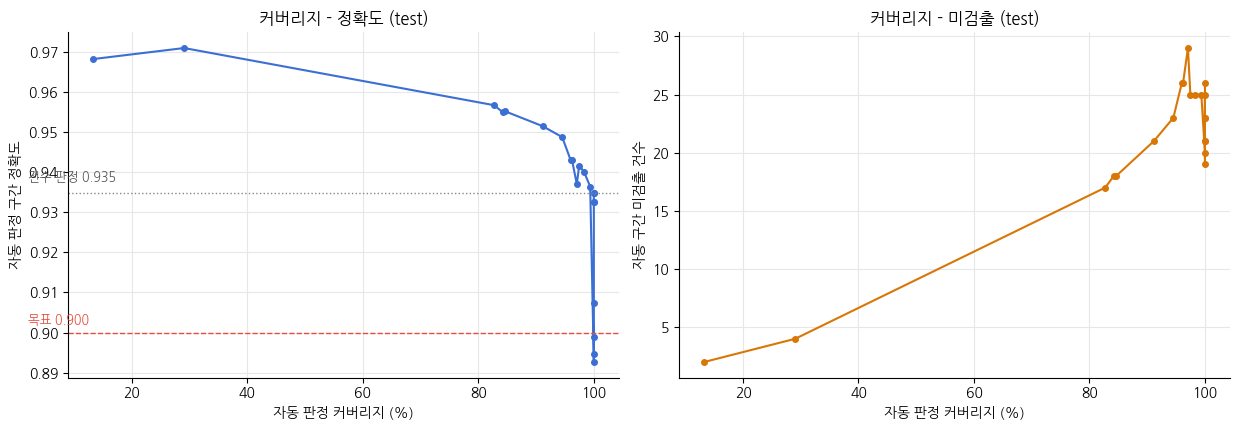

그래프 저장 coverage_curve.png


In [26]:
# @title 선택적 판정 (커버리지-정확도)
import numpy as np

ENS_SEL = [1, 2]
K_SEL = 8
TARGETS = [0.90, 0.93, 0.95, 0.98]
NQ = 150
MIN_N = 50
MIN_SIDE = 20

sv = torch.stack([Tv_all[j][:, :K_SEL].mean(1)[:, BIN_IDX]
                  for j in ENS_SEL]).mean(0).numpy()
st = torch.stack([Tt_all[j][:, :K_SEL].mean(1)[:, BIN_IDX]
                  for j in ENS_SEL]).mean(0).numpy()
yv = (Yv[:, BIN_IDX] > 0).numpy()
yt = (Yt[:, BIN_IDX] > 0).numpy()

def measure(s, y, lo, hi):
    low, high = s <= lo, s >= hi
    cov = low | high
    n = int(cov.sum())
    if n == 0:
        return (0.0, 0.0, 0, len(s), 0, 0, 0, 0)
    pb = s[cov] >= hi
    yy = y[cov]
    return (n / len(s), float((pb == yy).mean()), n, len(s) - n,
            int((~pb & yy).sum()), int((pb & ~yy).sum()),
            int(low.sum()), int(high.sum()))

def single_thr(s, y):
    cand = np.unique(s)
    accs = [float((((s >= t) & y) | ((s < t) & ~y)).mean()) for t in cand]
    return plateau_mid(list(cand), accs)

thr1 = single_thr(sv, yv)
v1, t1 = measure(sv, yv, thr1, thr1), measure(st, yt, thr1, thr1)
print("기준 조합 %s | k=%d | val %d장 / test %d장"
      % ("+".join("s%d" % SEEDS[j] for j in ENS_SEL), K_SEL, len(sv), len(st)))
print("전수 강제 판정 (단일 threshold %.4f)" % thr1)
print("  val 정확도 %.3f -> test 정확도 %.3f | 미검출 %d / 과검 %d"
      % (v1[1], t1[1], t1[4], t1[5]))

qs = np.unique(np.quantile(sv, np.linspace(0.0, 1.0, NQ)))
pairs = []
for lo in qs:
    for hi in qs[qs >= lo]:
        m = measure(sv, yv, lo, hi)
        if m[2] >= MIN_N and m[6] >= MIN_SIDE and m[7] >= MIN_SIDE:
            pairs.append((m[0], m[1], m[4], float(lo), float(hi), m[6], m[7]))
print("유효 경계 조합 %d개 (양쪽 각 %d장 이상)" % (len(pairs), MIN_SIDE))

print("")
print("=" * 104)
print("%8s | %-30s | %-44s" % ("목표", "val (기준 선택)", "test (실제 성능)"))
print("%8s | %9s %9s %7s | %9s %9s %7s %7s %6s"
      % ("정확도", "커버리지", "정확도", "보류", "커버리지", "정확도", "보류", "미검출", "과검"))
picks = []
for tg in TARGETS:
    ok = [q for q in pairs if q[1] >= tg]
    if not ok:
        print("%8.2f | 조건을 만족하는 구간 없음" % tg)
        continue
    b = max(ok, key=lambda q: q[0])
    tc = measure(st, yt, b[3], b[4])
    picks.append(("정확도 %.2f" % tg, b, tc))
    print("%8.2f | %8.1f%% %9.3f %7d | %8.1f%% %9.3f %7d %7d %6d"
          % (tg, 100 * b[0], b[1], len(sv) - b[5] - b[6],
             100 * tc[0], tc[1], tc[3], tc[4], tc[5]))

zero = [q for q in pairs if q[2] == 0 and q[1] >= 0.90]
if zero:
    bz = max(zero, key=lambda q: q[0])
    tz = measure(st, yt, bz[3], bz[4])
    picks.append(("미검출 0", bz, tz))
    print("-" * 104)
    print("%8s | %8.1f%% %9.3f %7d | %8.1f%% %9.3f %7d %7d %6d"
          % ("미검출0", 100 * bz[0], bz[1], len(sv) - bz[5] - bz[6],
             100 * tz[0], tz[1], tz[3], tz[4], tz[5]))
else:
    print("-" * 104)
    print("미검출0 | val에서 불량을 하나도 놓치지 않는 유효 구간 없음")
print("=" * 104)

for tag, b, tc in picks:
    if tc[1] >= 0.9:
        print("[%s] 경계 [%.4f, %.4f]" % (tag, b[3], b[4]))
        print("  자동 양품 %d장 / 자동 불량 %d장 = %d장(%.1f%%) 자동 판정"
              % (tc[6], tc[7], tc[2], 100 * tc[0]))
        print("  자동 구간 정확도 %.3f | 미검출 %d / 과검 %d"
              % (tc[1], tc[4], tc[5]))
        print("  육안 확인 %d장 (%.1f%%)" % (tc[3], 100 * (1 - tc[0])))
        print("")

curve = []
for tg in np.arange(0.88, 0.996, 0.005):
    ok = [q for q in pairs if q[1] >= tg]
    if not ok:
        continue
    b = max(ok, key=lambda q: q[0])
    tc = measure(st, yt, b[3], b[4])
    curve.append((tc[0], tc[1], tc[4]))
curve = sorted(set(curve))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
ax.plot([c[0] * 100 for c in curve], [c[1] for c in curve], "o-",
        color="#3b6fd4", ms=4)
ax.axhline(0.9, color="#e74c3c", ls="--", lw=1)
ax.axhline(t1[1], color="#888", ls=":", lw=1)
ax.text(2, 0.902, "목표 0.900", color="#e74c3c", fontsize=9)
ax.text(2, t1[1] + 0.003, "전수 판정 %.3f" % t1[1], color="#555", fontsize=9)
ax.set_xlabel("자동 판정 커버리지 (%)")
ax.set_ylabel("자동 판정 구간 정확도")
ax.set_title("커버리지 - 정확도 (test)")
ax.grid(color="#e5e7eb", lw=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.plot([c[0] * 100 for c in curve], [c[2] for c in curve], "o-",
        color="#d97706", ms=4)
ax.set_xlabel("자동 판정 커버리지 (%)")
ax.set_ylabel("자동 구간 미검출 건수")
ax.set_title("커버리지 - 미검출 (test)")
ax.grid(color="#e5e7eb", lw=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("coverage_curve.png", dpi=130, bbox_inches="tight")
plt.show()
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy("coverage_curve.png", "/content/drive/MyDrive/coverage_curve.png")
print("그래프 저장 coverage_curve.png")

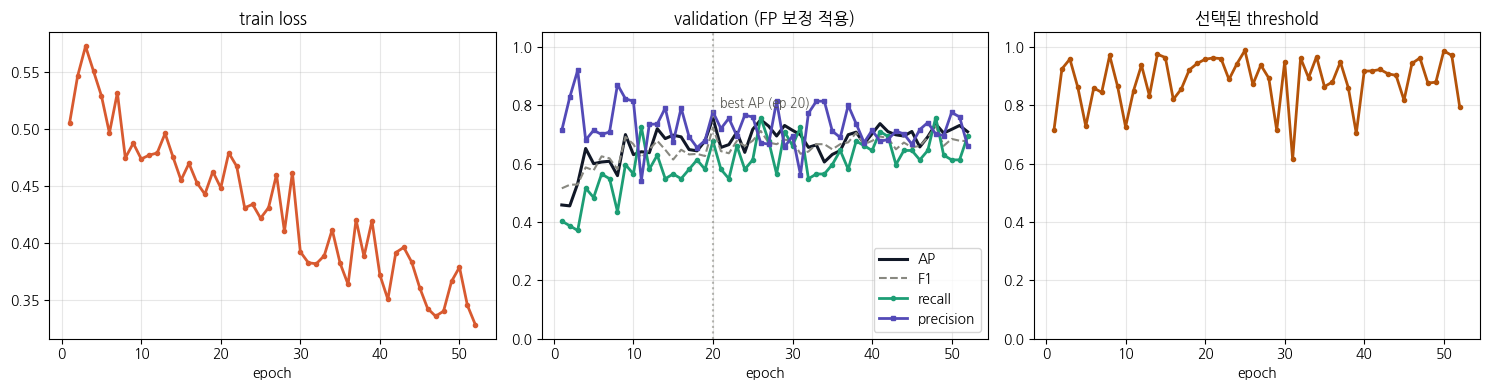

In [27]:
# @title 그래프로 나타내기 (MIL)
import matplotlib.pyplot as plt

losses, recs, precs, f1s, thrs, aps = zip(*history_ml)
ex = range(1, len(losses) + 1)
best_ep = max(range(len(aps)), key=lambda i: aps[i])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(ex, losses, color="#D85A30", lw=2, marker="o", ms=3)
ax[0].set_title("train loss")
ax[0].set_xlabel("epoch")
ax[0].grid(alpha=0.3)

ax[1].plot(ex, aps, color="#111827", lw=2.2, label="AP")
ax[1].plot(ex, f1s, color="#888880", lw=1.5, ls="--", label="F1")
ax[1].plot(ex, recs, color="#1D9E75", lw=2, marker="o", ms=3, label="recall")
ax[1].plot(ex, precs, color="#534AB7", lw=2, marker="s", ms=3, label="precision")
ax[1].axvline(best_ep + 1, color="#888880", ls=":", alpha=0.6)
ax[1].annotate(f"best AP (ep {best_ep + 1})", xy=(best_ep + 1, aps[best_ep]),
               xytext=(5, 8), textcoords="offset points", fontsize=9, color="#555550")
ax[1].set_title("validation (FP 보정 적용)")
ax[1].set_xlabel("epoch")
ax[1].set_ylim(0, 1.05)
ax[1].grid(alpha=0.3)
ax[1].legend(loc="lower right")

ax[2].plot(ex, thrs, color="#B45309", lw=2, marker="o", ms=3)
ax[2].set_title("선택된 threshold")
ax[2].set_xlabel("epoch")
ax[2].set_ylim(0, 1.05)
ax[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

가중치 best_mil.pth
[양/불]  test 475 die (불량 62, 13.1%) | 집계 상위 4개 평균 | TTA on
  thr 0.768  <- val에서 정확도 최대 구간의 중앙값
  val 정확도 0.922 -> test 정확도 0.937
  acc 0.937  (기준선 0.869, 목표 0.900)
  recall 0.548 [0.418, 0.676] | precision 0.944 [0.865, 1.000] | F1 0.694
  AP 0.757  (기저 0.131, 5.80배)
  TP 34  FN 28  FP 2  TN 411
------------------------------------------------------------------------------
운영점                  thr     정확도  recall  precision     과검
정확도 최대             0.768   0.937   0.548      0.944      2
F1 최대              0.589   0.916   0.597      0.712     15
recall 0.95        0.201   0.423   0.952      0.179    271
미검출 0              0.180   0.244   1.000      0.147    359
[원인]  불량 62장 안에서만 계산 | threshold는 val에서 지표별 고정
원인      thr   GT   검출   놓침    오검출  recall   prec     F1
P     0.070   39   39    0     22   1.000  0.639  0.780
S     0.342    8    5    3      7   0.625  0.417  0.500

정확도 0.9까지 0장 — 달성


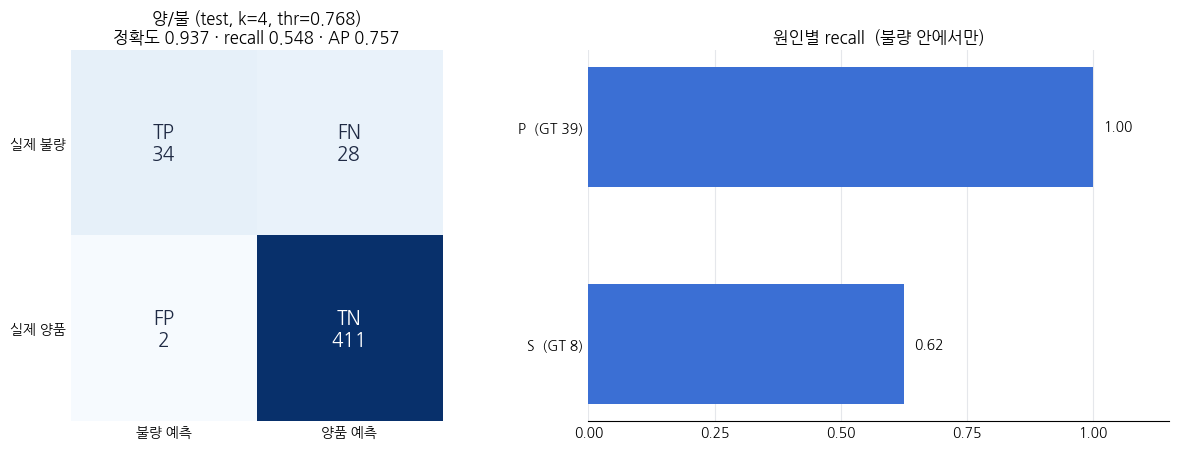

In [28]:
# @title 최종 평가 (val threshold 고정)
import numpy as np

K_AGG = 4
THR_MODE = "acc"
CKPT_CANDIDATES = ("best_mil.pth", "/content/drive/MyDrive/best_mil.pth")

wpath = next((q for q in CKPT_CANDIDATES if os.path.exists(q)), None)
assert wpath, "가중치를 찾지 못함 — MIL 학습 셀을 돌리거나 드라이브 마운트를 확인하세요"
model_ml.load_state_dict(torch.load(wpath, map_location=DEVICE))
if wpath != "best_mil.pth":
    shutil.copy(wpath, "best_mil.pth")
print("가중치 %s" % wpath)

def collect_agg(model, items, device, k=K_AGG):
    model.eval()
    T = torch.stack([die_topvals(model, p, device) for p, _ in items])
    Y = torch.stack([letter_vec(g) for _, g in items])
    return T[:, :k].mean(1), Y

def acc_of(Sx, Yx, thr):
    _, _, _, (a, b, c, d) = binary_metrics(Sx, Yx, thr)
    return (a + d) / len(Sx)

def best_acc_thr(Sx, Yx):
    cand = sorted(set(Sx[:, BIN_IDX].tolist()))
    return plateau_mid(cand, [acc_of(Sx, Yx, t) for t in cand])

S_va, Y_va = collect_agg(model_ml, va_items, DEVICE)
THR_F1 = best_thr(S_va, Y_va)
THR_ACC = best_acc_thr(S_va, Y_va)
THR_BIN = THR_ACC if THR_MODE == "acc" else THR_F1
THR_R95 = thr_at_recall(S_va, Y_va, 0.95)
THR_R100 = thr_at_recall(S_va, Y_va, 1.0)
THR_LET = best_letter_thr(S_va, Y_va)

S, Y = collect_agg(model_ml, te_items, DEVICE)
r, p, f1, (tp, fp, fn, tn) = binary_metrics(S, Y, THR_BIN)
acc = (tp + tn) / len(S)
ap = average_precision(S, Y)
(r_lo, r_hi), (p_lo, p_hi) = bootstrap_ci(S, Y, THR_BIN)

is_bad = Y[:, BIN_IDX] > 0
n_bad_te = int(is_bad.sum())
prev = n_bad_te / len(S)

rows, skipped = [], []
for j, L in enumerate(LETTERS):
    gt = Y[is_bad, j] > 0
    if THR_LET[L] is None or int(gt.sum()) < MIN_REPORT:
        skipped.append(f"{L}(GT {int(gt.sum())})")
        continue
    pr = S[is_bad, j] >= THR_LET[L]
    det = int((gt & pr).sum())
    miss = int((gt & ~pr).sum())
    fa = int((~gt & pr).sum())
    rec = det / max(det + miss, 1)
    prec = det / max(det + fa, 1)
    rows.append((L, THR_LET[L], det + miss, det, miss, fa, rec, prec,
                 2 * rec * prec / max(rec + prec, 1e-9)))

print("=" * 78)
print(f"[양/불]  test {len(S)} die (불량 {n_bad_te}, {prev:.1%}) | 집계 상위 {K_AGG}개 평균"
      f" | TTA {'on' if TTA_EVAL else 'off'}")
print(f"  thr {THR_BIN:.3f}  <- val에서 {'정확도' if THR_MODE == 'acc' else 'F1'} 최대 구간의 중앙값")
print(f"  val 정확도 {acc_of(S_va, Y_va, THR_BIN):.3f} -> test 정확도 {acc:.3f}")
print(f"  acc {acc:.3f}  (기준선 {1 - prev:.3f}, 목표 0.900)")
print(f"  recall {r:.3f} [{r_lo:.3f}, {r_hi:.3f}] | precision {p:.3f} "
      f"[{p_lo:.3f}, {p_hi:.3f}] | F1 {f1:.3f}")
print(f"  AP {ap:.3f}  (기저 {prev:.3f}, {ap / max(prev, 1e-9):.2f}배)")
print(f"  TP {tp}  FN {fn}  FP {fp:.0f}  TN {tn:.0f}")
print("-" * 78)
print(f"{'운영점':16s} {'thr':>7s} {'정확도':>7s} {'recall':>7s} {'precision':>10s} {'과검':>6s}")
for tag, t_ in (("정확도 최대", THR_ACC), ("F1 최대", THR_F1),
                ("recall 0.95", THR_R95), ("미검출 0", THR_R100)):
    rr, pp, _, (_, ff, _, dd) = binary_metrics(S, Y, t_)
    print(f"{tag:16s} {t_:>7.3f} {acc_of(S, Y, t_):>7.3f} {rr:>7.3f} "
          f"{pp:>10.3f} {ff:>6.0f}")
print("=" * 78)
print(f"[원인]  불량 {n_bad_te}장 안에서만 계산 | threshold는 val에서 지표별 고정")
print(f"{'원인':4s} {'thr':>6s} {'GT':>4s} {'검출':>4s} {'놓침':>4s} {'오검출':>6s} "
      f"{'recall':>7s} {'prec':>6s} {'F1':>6s}")
for L, t_, n_, det, miss, fa, rec, prec, f1l in rows:
    print(f"{L:4s} {t_:>6.3f} {n_:>4d} {det:>4d} {miss:>4d} {fa:>6d} "
          f"{rec:>7.3f} {prec:>6.3f} {f1l:>6.3f}")
if skipped:
    print(f"\n표본 부족으로 보고 제외 (GT < {MIN_REPORT}): {', '.join(skipped)}")
short = int(-(-0.9 * len(S) // 1)) - (tp + int(tn))
print(f"\n정확도 0.9까지 {max(short, 0)}장" + (" 부족" if short > 0 else " — 달성"))
print("=" * 78)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
cm = np.array([[tp, fn], [int(round(fp)), int(round(tn))]])
ax = axes[0]
ax.imshow(cm, cmap="Blues", vmin=0)
tags = [["TP", "FN"], ["FP", "TN"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{tags[i][j]}\n{cm[i, j]}", ha="center", va="center",
                fontsize=14, fontweight="bold",
                color="white" if cm[i, j] > cm.max() * 0.55 else "#1f2a44")
ax.set_xticks([0, 1])
ax.set_xticklabels(["불량 예측", "양품 예측"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["실제 불량", "실제 양품"])
ax.set_title(f"양/불 (test, k={K_AGG}, thr={THR_BIN:.3f})\n"
             f"정확도 {acc:.3f} · recall {r:.3f} · AP {ap:.3f}")
for s_ in ax.spines.values():
    s_.set_visible(False)
ax.tick_params(length=0)

ax = axes[1]
if rows:
    ys = np.arange(len(rows))[::-1]
    ax.barh(ys, [row[6] for row in rows], height=0.55, color="#3b6fd4")
    for y_, row in zip(ys, rows):
        ax.text(max(row[6], 0.02) + 0.02, y_, f"{row[6]:.2f}", va="center", fontsize=10)
    ax.set_yticks(ys)
    ax.set_yticklabels([f"{row[0]}  (GT {row[2]})" for row in rows])
ax.set_xlim(0, 1.15)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_title("원인별 recall  (불량 안에서만)")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(length=0)
ax.xaxis.grid(True, color="#e5e7eb", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [29]:
# @title TTA A/B
import time
import numpy as np

K_LIST = [1, 2, 4, 8, 16]

model_ml.load_state_dict(torch.load("best_mil.pth"))
model_ml.eval()

def collect_top(items, tta):
    T = torch.stack([die_topvals(model_ml, p, DEVICE, tta=tta) for p, _ in items])
    Y = torch.stack([letter_vec(g) for _, g in items])
    return T, Y

def acc_of2(Sx, Yx, thr):
    _, _, _, (a, b, c, d) = binary_metrics(Sx, Yx, thr)
    return (a + d) / len(Sx)

def pick_thr(Sx, Yx):
    cand = sorted(set(Sx[:, BIN_IDX].tolist()))
    return plateau_mid(cand, [acc_of2(Sx, Yx, t) for t in cand])

cache = {}
for tta in (False, True):
    t0 = time.time()
    Tv, Yv = collect_top(va_items, tta)
    Tt, Yt = collect_top(te_items, tta)
    cache[tta] = (Tv, Yv, Tt, Yt, time.time() - t0)
    print("TTA %-5s 계산 완료 %.0f초" % (str(tta), cache[tta][4]), flush=True)

print("")
print("=" * 88)
print("%5s %4s %10s %9s %10s %9s %8s %10s %6s %6s"
      % ("TTA", "k", "val정확도", "thr", "test정확도", "test AP", "recall",
         "precision", "미검출", "과검"))
rows = []
for tta in (False, True):
    Tv, Yv, Tt, Yt, _ = cache[tta]
    for k in K_LIST:
        Sv, St = Tv[:, :k].mean(1), Tt[:, :k].mean(1)
        thr = pick_thr(Sv, Yv)
        r_, p_, _, (tp_, fp_, fn_, tn_) = binary_metrics(St, Yt, thr)
        rows.append((tta, k, acc_of2(Sv, Yv, thr), thr, acc_of2(St, Yt, thr),
                     average_precision(St, Yt), r_, p_, fn_, int(fp_)))
best = max(rows, key=lambda v: v[2])
for v in rows:
    mark = "  <- val 기준 선택" if v is best else ""
    print("%5s %4d %10.3f %9.3f %10.3f %9.3f %8.3f %10.3f %6d %6d%s"
          % (str(v[0]), v[1], v[2], v[3], v[4], v[5], v[6], v[7], v[8], v[9], mark))
print("-" * 88)
base = [v for v in rows if v[0] is False and v[1] == 4][0]
print("기준 (TTA off, k=4)  test 정확도 %.3f / AP %.3f" % (base[4], base[5]))
print("선택 (TTA %s, k=%d)   test 정확도 %.3f / AP %.3f  (%+.3f)"
      % (best[0], best[1], best[4], best[5], best[4] - base[4]))
need = int(np.ceil(0.9 * len(te_items))) - int(round(best[4] * len(te_items)))
print("정확도 0.9까지 %d장" % max(need, 0))
print("=" * 88)
print("좋은 쪽으로 나오면 최종 평가 셀의 K_AGG 를 %d 로 두고 다시 실행하세요" % best[1])

TTA False 계산 완료 47초
TTA True  계산 완료 177초

  TTA    k     val정확도       thr    test정확도   test AP   recall  precision    미검출     과검
False    1      0.931     0.999      0.924     0.731    0.468      0.906     33      3
False    2      0.928     0.998      0.914     0.732    0.387      0.889     38      3
False    4      0.928     0.994      0.918     0.745    0.403      0.926     37      2
False    8      0.933     0.950      0.912     0.730    0.371      0.885     39      3  <- val 기준 선택
False   16      0.928     0.782      0.903     0.713    0.323      0.833     42      4
 True    1      0.920     0.734      0.922     0.731    0.613      0.745     24     13
 True    2      0.920     0.899      0.924     0.737    0.468      0.906     33      3
 True    4      0.922     0.768      0.937     0.757    0.548      0.944     28      2
 True    8      0.928     0.640      0.924     0.756    0.468      0.906     33      3
 True   16      0.928     0.415      0.918     0.739    0.532      0.767  

In [30]:
# @title 체크포인트 저장 (가중치 + 설정 + threshold)
import json, hashlib, datetime, time

CKPT = "phosem_v3.pt"
META_JSON = "phosem_v3_meta.json"
DRIVE_DIR = "/content/drive/MyDrive"

is_resnet = any(m.__class__.__name__ == "ResNet" for m in model_ml.modules())
builder = ("사전학습 백본 MIL 모델 셀 (ResNet18 + ImageNetNorm)" if is_resnet
           else "MIL 모델 셀 (자체 build_mil_cnn)")
n_bad_ckpt = int((Y[:, BIN_IDX] > 0).sum())
prev_ckpt = n_bad_ckpt / len(S)

meta = {
    "builder_cell": builder,
    "arch": "resnet18_imagenet" if is_resnet else "build_mil_cnn",
    "n_params": sum(p.numel() for p in model_ml.parameters()),
    "input_norm": "imagenet" if is_resnet else "none",
    "letters": LETTERS, "bin_idx": BIN_IDX,
    "patch": PATCH, "stride": STRIDE,
    "roi_box": list(ROI_C),
    "k_ring": K_RING, "k_box": K_BOX, "k_rand": K_RAND,
    "ring_jitter": RING_JITTER, "n_ring_eval": N_RING_EVAL,
    "mesa_source": "hough_per_image", "mesa_fallback": list(MESA_FALLBACK),
    "agg": f"topk{K_AGG}_mean", "k_agg": K_AGG,
    "thr_mode": THR_MODE,
    "thr_bin": float(THR_BIN), "thr_acc": float(THR_ACC), "thr_f1": float(THR_F1),
    "thr_r95": float(THR_R95), "thr_r100": float(THR_R100),
    "thr_letter": {k: (None if v is None else float(v)) for k, v in THR_LET.items()},
    "class_names": CLASS_NAMES,
    "drop_letters": DROP_LETTERS,
    "excluded_tags": sorted(EXCLUDE_TAGS),
    "require_clean_bg": REQUIRE_CLEAN_BG,
    "split_seed": 42,
    "n_train": len(tr_items), "n_val": len(va_items), "n_test": len(te_items),
    "test_n_bad": n_bad_ckpt, "test_prevalence": round(prev_ckpt, 4),
    "baseline_acc": round(1 - prev_ckpt, 4), "baseline_ap": round(prev_ckpt, 4),
    "test_ap": float(ap), "ap_over_baseline": round(float(ap) / max(prev_ckpt, 1e-9), 2),
    "test_recall": float(r), "test_precision": float(p), "test_acc": float(acc),
    "torch": torch.__version__,
    "saved_at": datetime.datetime.now().isoformat(timespec="seconds"),
}
torch.save({"state_dict": model_ml.state_dict(), "meta": meta}, CKPT)
h = hashlib.sha256(open(CKPT, "rb").read()).hexdigest()[:16]
json.dump({**meta, "sha256_16": h}, open(META_JSON, "w"),
          ensure_ascii=False, indent=2)

print(f"로컬 저장 완료 /content/{CKPT}  "
      f"({os.path.getsize(CKPT) / 1024 / 1024:.1f} MB)  sha256 {h}")
print(json.dumps(meta, ensure_ascii=False, indent=2))

def copy_to_drive(paths, retry=2):
    for attempt in range(retry + 1):
        try:
            os.makedirs(DRIVE_DIR, exist_ok=True)
            for p_ in paths:
                shutil.copy(p_, os.path.join(DRIVE_DIR, os.path.basename(p_)))
            return True
        except OSError as e:
            print(f"드라이브 복사 실패 {attempt + 1}/{retry + 1}: {e}")
            if attempt == retry:
                return False
            try:
                from google.colab import drive
                drive.flush_and_unmount()
                time.sleep(5)
                drive.mount("/content/drive", force_remount=True)
                print("재마운트 완료, 재시도합니다")
            except Exception as e2:
                print("재마운트 실패:", e2)
                return False
    return False

if copy_to_drive([CKPT, META_JSON]):
    print(f"\n드라이브 복사 완료 {DRIVE_DIR}/{CKPT}")
else:
    print("\n드라이브에 못 올렸습니다. 로컬 파일은 정상이니 직접 내려받으세요")
    try:
        from google.colab import files
        files.download(CKPT)
        files.download(META_JSON)
    except Exception as e:
        print("자동 다운로드 실패:", e)
        print(f"좌측 파일 탭에서 {CKPT} 우클릭 → 다운로드")

로컬 저장 완료 /content/phosem_v3.pt  (42.7 MB)  sha256 56b22bb23f40855f
{
  "builder_cell": "사전학습 백본 MIL 모델 셀 (ResNet18 + ImageNetNorm)",
  "arch": "resnet18_imagenet",
  "n_params": 11178051,
  "input_norm": "imagenet",
  "letters": "PS",
  "bin_idx": 2,
  "patch": 128,
  "stride": 64,
  "roi_box": [
    384,
    236,
    564,
    416
  ],
  "k_ring": 3,
  "k_box": 2,
  "k_rand": 7,
  "ring_jitter": 12,
  "n_ring_eval": 16,
  "mesa_source": "hough_per_image",
  "mesa_fallback": [
    522.0,
    277.0,
    116.0
  ],
  "agg": "topk4_mean",
  "k_agg": 4,
  "thr_mode": "acc",
  "thr_bin": 0.7678462266921997,
  "thr_acc": 0.7678462266921997,
  "thr_f1": 0.5885791778564453,
  "thr_r95": 0.2009890079498291,
  "thr_r100": 0.17989963293075562,
  "thr_letter": {
    "P": 0.07006346434354782,
    "S": 0.341955304145813
  },
  "class_names": [
    "양품",
    "P",
    "S",
    "PS",
    "공식불량"
  ],
  "drop_letters": "BC",
  "excluded_tags": [
    "D",
    "F",
    "U",
    "X"
  ],
  "require_clean_bg"

In [31]:
# @title 환경 기록 (requirements.txt)
ENV_OUT = "requirements.txt"

!pip freeze > {ENV_OUT}
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(ENV_OUT, "/content/drive/MyDrive/" + ENV_OUT)

print(f"torch {torch.__version__} | torchvision {__import__('torchvision').__version__} "
      f"| CUDA {torch.cuda.is_available()}")
print(f"저장 완료: {ENV_OUT}")

torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | CUDA True
저장 완료: requirements.txt


In [32]:
# @title 데이터 목록 내보내기 (train/val/test)
import csv

SPLIT_OUT = "phosem_v3_split.csv"

overlap_tv = {p for p, _ in tr_items} & {p for p, _ in va_items}
overlap_tt = {p for p, _ in tr_items} & {p for p, _ in te_items}
overlap_vt = {p for p, _ in va_items} & {p for p, _ in te_items}

with open(SPLIT_OUT, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "분할", "라벨"])
    for split_name, items in (("train", tr_items), ("val", va_items), ("test", te_items)):
        for p, c in items:
            wr.writerow([os.path.basename(p), split_name, CLASS_NAMES[c]])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(SPLIT_OUT, "/content/drive/MyDrive/" + SPLIT_OUT)

print(f"저장 완료: {SPLIT_OUT}  (train {len(tr_items)} / val {len(va_items)} / test {len(te_items)})")
print("분할 방법: 클래스별 shuffle(seed 42) 후 test 20% / val 20% / train 나머지")
print(f"train-val 겹침 {len(overlap_tv)}장 | train-test 겹침 {len(overlap_tt)}장 | val-test 겹침 {len(overlap_vt)}장")

저장 완료: phosem_v3_split.csv  (train 1440 / val 475 / test 475)
분할 방법: 클래스별 shuffle(seed 42) 후 test 20% / val 20% / train 나머지
train-val 겹침 0장 | train-test 겹침 0장 | val-test 겹침 0장


In [33]:
# @title FP / FN 목록
import os
from collections import Counter

score = S[:, BIN_IDX]
pred = score >= THR_BIN
is_bad = Y[:, BIN_IDX] > 0

fp_list = [(te_items[i][0], float(score[i]), LETTERS[int(S[i, :len(LETTERS)].argmax())])
           for i in range(len(S)) if pred[i] and not is_bad[i]]
fn_list = [(te_items[i][0], float(score[i]), CLASS_NAMES[te_items[i][1]])
           for i in range(len(S)) if not pred[i] and is_bad[i]]

print(f"[FP {len(fp_list)}건]  양품인데 불량 판정 — 라벨 오류 여부 확인 대상")
for path, s, L in sorted(fp_list, key=lambda v: -v[1]):
    print(f"  {os.path.basename(path):45s} 점수 {s:.3f}  최고지표 {L}")

print(f"\n[FN {len(fn_list)}건]  불량인데 놓침")
for path, s, cls in sorted(fn_list, key=lambda v: v[1]):
    print(f"  {os.path.basename(path):45s} 점수 {s:.3f}  정답 {cls}")

print(f"\nFP 최고지표 분포 {dict(Counter(L for _, _, L in fp_list))}")
print(f"FN 정답 분포     {dict(Counter(c for _, _, c in fn_list))}")

[FP 2건]  양품인데 불량 판정 — 라벨 오류 여부 확인 대상
  518-die-양-O.jpg                             점수 0.856  최고지표 P
  510-die-양-O.jpg                             점수 0.823  최고지표 P

[FN 28건]  불량인데 놓침
  489-die-불-pPB.jpg                           점수 0.187  정답 P
  379.jpg                                       점수 0.190  정답 공식불량
  676-die-불-pPBC.jpg                          점수 0.193  정답 P
  539-die-불-P.jpg                             점수 0.201  정답 P
  450.jpg                                       점수 0.202  정답 공식불량
  211-die-불-pP.jpg                            점수 0.204  정답 P
  1004.jpg                                      점수 0.205  정답 공식불량
  1010-die-불-pP.jpg                           점수 0.209  정답 P
  853-die-불-S.jpg                             점수 0.211  정답 S
  182.jpg                                       점수 0.226  정답 공식불량
  139-die-불-pP.jpg                            점수 0.232  정답 P
  78-die-불-P.jpg                              점수 0.250  정답 P
  132-die-불-P.jpg                           

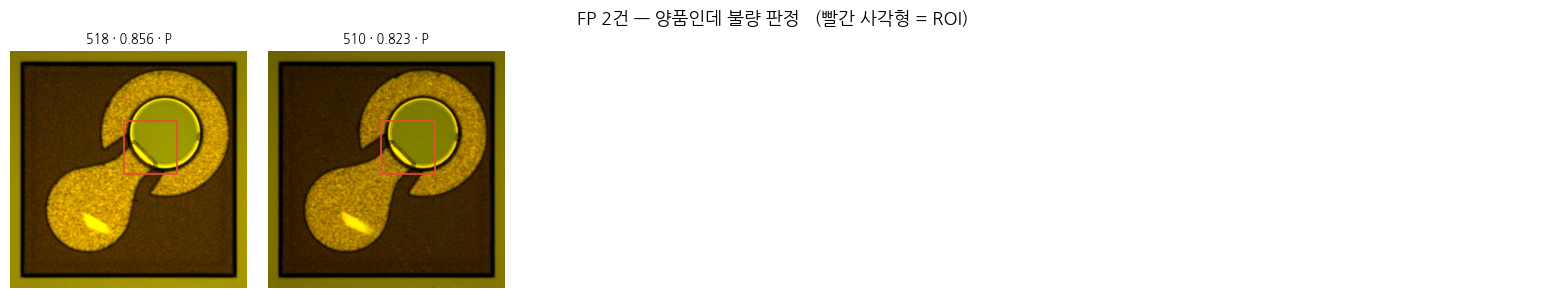

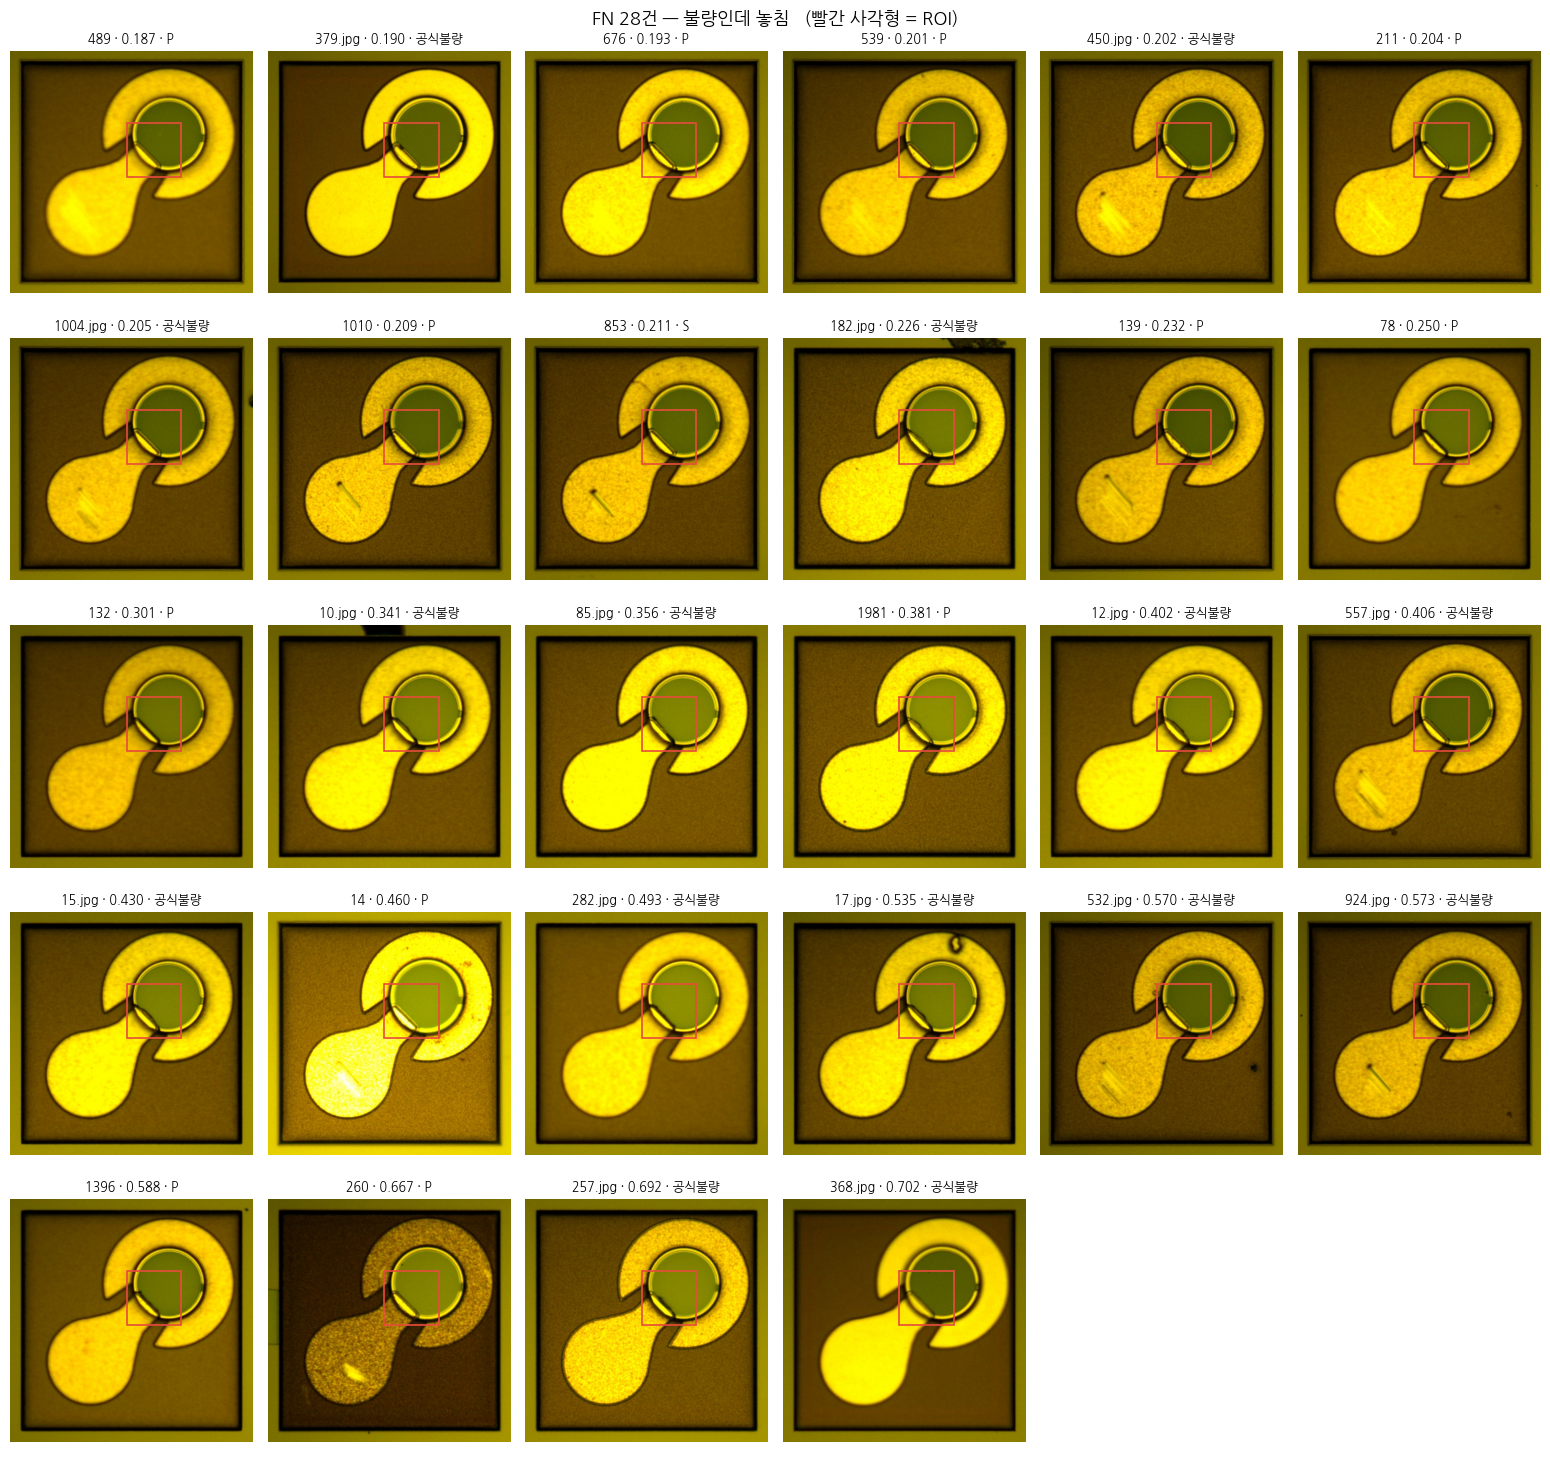


검토표 저장 /content/drive/MyDrive/label_review.csv  (30행)
판정 열에 '오류' 또는 '정상'을 채운 뒤 같은 경로에 덮어쓰세요
오답 30건 중 -17건이 '오류'로 판명되면 정확도 0.9입니다


In [34]:
# @title FP / FN 이미지 격자 보기
import csv
import numpy as np
import matplotlib.patches as mpatches
from PIL import Image

REVIEW_CSV = "label_review.csv"
COLS, THUMB = 6, 2.6

def show_grid(items, title):
    if not items:
        print(f"{title}: 없음")
        return
    n = len(items)
    rows_n = (n + COLS - 1) // COLS
    fig, axes = plt.subplots(rows_n, COLS,
                             figsize=(COLS * THUMB, rows_n * THUMB * 1.15))
    axes = np.atleast_1d(axes).ravel()
    for ax, (path, sc, lab) in zip(axes, items):
        ax.imshow(Image.open(path).convert("RGB"))
        x0, y0, x1, y1 = ROI_C
        ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                        fill=False, ec="#e74c3c", lw=1.2))
        ax.set_title(f"{os.path.basename(path).split('-')[0]} · {sc:.3f} · {lab}",
                     fontsize=9)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"{title}   (빨간 사각형 = ROI)", fontsize=13)
    plt.tight_layout()
    plt.show()

fp_sorted = sorted(fp_list, key=lambda v: -v[1])
fn_sorted = sorted(fn_list, key=lambda v: v[1])
show_grid(fp_sorted, f"FP {len(fp_sorted)}건 — 양품인데 불량 판정")
show_grid(fn_sorted, f"FN {len(fn_sorted)}건 — 불량인데 놓침")

with open(REVIEW_CSV, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "구분", "점수", "현재라벨", "판정"])
    for path, sc, _ in fp_sorted:
        wr.writerow([os.path.basename(path), "FP", f"{sc:.3f}", "양품", ""])
    for path, sc, lab in fn_sorted:
        wr.writerow([os.path.basename(path), "FN", f"{sc:.3f}", lab, ""])

shutil.copy(REVIEW_CSV, "/content/drive/MyDrive/" + REVIEW_CSV)
n_total = len(fp_sorted) + len(fn_sorted)
need = int(np.ceil(0.9 * len(S))) - (tp + int(tn))
print(f"\n검토표 저장 /content/drive/MyDrive/{REVIEW_CSV}  ({n_total}행)")
print("판정 열에 '오류' 또는 '정상'을 채운 뒤 같은 경로에 덮어쓰세요")
print(f"오답 {n_total}건 중 {need}건이 '오류'로 판명되면 정확도 0.9입니다")

In [35]:
# @title 라벨 검토 반영 재계산
import csv
import unicodedata
import numpy as np

MARK_OK = """
366-die-양-O.jpg
315-die-양-O.jpg
520-die-양-O.jpg
1056-die-양-po.jpg
126-die-양-po.jpg
2047-die-양-po.jpg
"""

MARK_BAD = """
1035-die-불-pC.jpg
"""

REVIEW_IN = "/content/drive/MyDrive/label_review.csv"
OK_WORDS = {"양품", "정상", "ok", "o"}
BAD_WORDS = {"불량", "오류", "ng", "x"}

def nkey(name):
    return unicodedata.normalize("NFC", os.path.basename(str(name)).strip())

def _names(block):
    return {nkey(t) for t in block.split() if t.strip().endswith(".jpg")}

ok_set, bad_set = _names(MARK_OK), _names(MARK_BAD)
if os.path.exists(REVIEW_IN):
    n_csv = 0
    with open(REVIEW_IN, encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            v = (row.get("판정") or "").strip().lower()
            nm = nkey(row.get("파일명") or "")
            if not nm or not v:
                continue
            n_csv += 1
            if v in OK_WORDS:
                ok_set.add(nm)
            elif v in BAD_WORDS:
                bad_set.add(nm)
    print("검토표에서 판정 %d건 추가로 읽음" % n_csv)
print("표기 합계: 라벨 정상 %d건 / 라벨 오류 %d건" % (len(ok_set), len(bad_set)))

score_b = S[:, BIN_IDX]
y0 = Y[:, BIN_IDX] > 0
pred_b = score_b >= THR_BIN
N_TE = len(te_items)

def metrics(y):
    a = int((pred_b & y).sum())
    b = int((~pred_b & y).sum())
    c = int((pred_b & ~y).sum())
    d = int((~pred_b & ~y).sum())
    return ((a + d) / N_TE, a / max(a + b, 1), a / max(a + c, 1), a, b, c, d)

confirmed, pending, settled = set(), set(), set()
seen = set()
for i, (path, _) in enumerate(te_items):
    if bool(pred_b[i]) == bool(y0[i]):
        continue
    nm = nkey(path)
    seen.add(nm)
    now_bad = bool(y0[i])
    if nm in bad_set or (now_bad and nm in ok_set):
        confirmed.add(i)
    elif nm in ok_set:
        settled.add(i)
    else:
        pending.add(i)

def flipped(idx):
    y = y0.clone()
    for i in idx:
        y[i] = ~y[i]
    return y

cur = metrics(y0)
lo = metrics(flipped(confirmed))
hi = metrics(flipped(confirmed | pending))
n_wrong = len(confirmed) + len(pending) + len(settled)
need = int(np.ceil(0.9 * N_TE)) - int(round(cur[0] * N_TE))
unmatched = (ok_set | bad_set) - seen

print("=" * 78)
print("오답 %d건 | 라벨오류 확정 %d | 판정 보류 %d | 라벨정상 확정 %d"
      % (n_wrong, len(confirmed), len(pending), len(settled)))
if unmatched:
    print("현재 오답 목록에 없어 무시된 표기 %d건: %s"
          % (len(unmatched), ", ".join(sorted(unmatched))))
print("-" * 78)
print("%-18s %8s %8s %10s %5s %5s %5s %5s"
      % ("", "정확도", "recall", "precision", "TP", "FN", "FP", "TN"))
for tag, m in (("검토 전", cur), ("하한 (확정만)", lo), ("상한 (보류 포함)", hi)):
    print("%-18s %8.3f %8.3f %10.3f %5d %5d %5d %5d"
          % (tag, m[0], m[1], m[2], m[3], m[4], m[5], m[6]))
print("-" * 78)
if pending:
    print("정확도 0.9 까지 %d장 — 보류 %d건 중 %d건(%.0f%%)이 라벨 오류면 달성"
          % (max(need, 0), len(pending), max(need, 0),
             100 * max(need, 0) / len(pending)))
else:
    print("정확도 0.9 까지 %d장" % max(need, 0))
print("상한은 보류를 전부 라벨 오류로 가정한 값이라 실제 상한이 아닙니다")
print("=" * 78)

OUT = "label_pending.csv"
with open(OUT, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "구분", "점수", "현재라벨", "포셈판정"])
    for i in sorted(pending, key=lambda i: -float(score_b[i])):
        wr.writerow([os.path.basename(te_items[i][0]),
                     "FN" if y0[i] else "FP", "%.3f" % float(score_b[i]),
                     CLASS_NAMES[te_items[i][1]], ""])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT, "/content/drive/MyDrive/" + OUT)
print("판정 보류 %d건을 %s 로 저장 — 포셈 확인 요청용" % (len(pending), OUT))
print("학습에 반영하려면 같은 기준을 train/val 에도 적용하고 원본 파일명을 바꿔야 합니다")

검토표에서 판정 0건 추가로 읽음
표기 합계: 라벨 정상 6건 / 라벨 오류 1건
오답 30건 | 라벨오류 확정 0 | 판정 보류 30 | 라벨정상 확정 0
현재 오답 목록에 없어 무시된 표기 7건: 1035-die-불-pC.jpg, 1056-die-양-po.jpg, 126-die-양-po.jpg, 2047-die-양-po.jpg, 315-die-양-O.jpg, 366-die-양-O.jpg, 520-die-양-O.jpg
------------------------------------------------------------------------------
                        정확도   recall  precision    TP    FN    FP    TN
검토 전                  0.937    0.548      0.944    34    28     2   411
하한 (확정만)              0.937    0.548      0.944    34    28     2   411
상한 (보류 포함)            1.000    1.000      1.000    36     0     0   439
------------------------------------------------------------------------------
정확도 0.9 까지 0장 — 보류 30건 중 0건(0%)이 라벨 오류면 달성
상한은 보류를 전부 라벨 오류로 가정한 값이라 실제 상한이 아닙니다
판정 보류 30건을 label_pending.csv 로 저장 — 포셈 확인 요청용
학습에 반영하려면 같은 기준을 train/val 에도 적용하고 원본 파일명을 바꿔야 합니다


In [36]:
# @title 집계 방식 A/B
assert "KMAX" in globals(), "MIL 추론 / 지표 셀 맨 위에 KMAX = 16 이 있어야 합니다"

def collect_topvals(model, items, device):
    model.eval()
    T = torch.stack([die_topvals(model, p, device) for p, _ in items])
    Y = torch.stack([letter_vec(g) for _, g in items])
    return T, Y

def acc_of(Sx, Yx, thr):
    _, _, _, (a, b, c, d) = binary_metrics(Sx, Yx, thr)
    return (a + d) / len(Sx)

def best_acc_thr(Sx, Yx):
    cand = sorted(set(Sx[:, BIN_IDX].tolist()))
    return max(cand, key=lambda t: acc_of(Sx, Yx, t))

Tv, Yv = collect_topvals(model_ml, va_items, DEVICE)
Tt, Yt = collect_topvals(model_ml, te_items, DEVICE)

n_bad_ab = int((Yt[:, BIN_IDX] > 0).sum())
prev = n_bad_ab / len(Yt)
print(f"val {len(Yv)}장 | test {len(Yt)}장 | 불량 {n_bad_ab}장 ({prev:.1%}) "
      f"| 기준선 정확도 {1 - prev:.3f}\n")

res = []
for k in (1, 2, 4, 8, 16):
    Sv, St = Tv[:, :k].mean(1), Tt[:, :k].mean(1)
    apv, apt = average_precision(Sv, Yv), average_precision(St, Yt)
    t2 = best_acc_thr(Sv, Yv)
    va = acc_of(Sv, Yv, t2)
    ta = acc_of(St, Yt, t2)
    rc, pc, _, (_, ff, _, dd) = binary_metrics(St, Yt, t2)
    res.append((k, apv, va, t2, ta, apt, rc, pc, ff / max(ff + dd, 1)))

pick = max(res, key=lambda v: (v[2], v[1]))[0]
hdr = (f"{'k':>3s} {'val AP':>7s} {'val 정확도':>10s} | {'thr':>7s} "
       f"{'test 정확도':>11s} {'test AP':>8s} {'recall':>7s} {'prec':>6s} {'과검율':>7s}")
print(hdr)
print("-" * len(hdr))
for k, apv, va, t2, ta, apt, rc, pc, fpr in res:
    mark = "  <- val 기준 선택" if k == pick else ""
    print(f"{k:>3d} {apv:>7.3f} {va:>10.3f} | {t2:>7.3f} {ta:>11.3f} "
          f"{apt:>8.3f} {rc:>7.3f} {pc:>6.3f} {fpr:>7.3f}{mark}")

best = [v for v in res if v[0] == pick][0]
print(f"\nval 정확도 기준 k = {pick}  ->  test 정확도 {best[4]:.3f}")
print(f"최종 평가 셀의 K_AGG 를 {pick} 로 바꾸고 다시 실행하세요")
short = int(-(-0.9 * len(Yt) // 1)) - int(round(best[4] * len(Yt)))
if short > 0:
    print(f"정확도 0.9까지 {short}장 부족")

val 475장 | test 475장 | 불량 62장 (13.1%) | 기준선 정확도 0.869

  k  val AP    val 정확도 |     thr    test 정확도  test AP  recall   prec     과검율
----------------------------------------------------------------------------
  1   0.695      0.920 |   0.734       0.922    0.731   0.613  0.745   0.031
  2   0.701      0.920 |   0.899       0.924    0.737   0.468  0.906   0.007
  4   0.731      0.922 |   0.768       0.937    0.757   0.548  0.944   0.005
  8   0.747      0.928 |   0.640       0.924    0.756   0.468  0.906   0.007
 16   0.751      0.928 |   0.415       0.918    0.739   0.532  0.767   0.024  <- val 기준 선택

val 정확도 기준 k = 16  ->  test 정확도 0.918
최종 평가 셀의 K_AGG 를 16 로 바꾸고 다시 실행하세요


In [37]:
# @title 체크포인트 불러오기
import json, hashlib
import torchvision.models as tvm

CKPT_IN = "/content/drive/MyDrive/phosem_v3.pt"

assert os.path.exists(CKPT_IN), f"체크포인트 없음: {CKPT_IN}"
print("sha256", hashlib.sha256(open(CKPT_IN, "rb").read()).hexdigest()[:16])

blob = torch.load(CKPT_IN, map_location=DEVICE, weights_only=False)
m = blob["meta"]
print(json.dumps(m, ensure_ascii=False, indent=2))

if m["arch"] == "resnet18_imagenet":
    class ImageNetNorm(nn.Module):
        def __init__(self):
            super().__init__()
            self.register_buffer("m", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
            self.register_buffer("s", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

        def forward(self, x):
            return (x - self.m) / self.s

    net = tvm.resnet18(weights=None)
    net.fc = nn.Linear(net.fc.in_features, len(m["letters"]) + 1)
    model_load = nn.Sequential(ImageNetNorm(), net)
else:
    model_load = build_mil_cnn(tuple(m.get("channels", (16, 32, 64))),
                               len(m["letters"]) + 1, m.get("pool", 4))

model_load.load_state_dict(blob["state_dict"])
model_load = model_load.to(DEVICE).eval()
print(f"\n로드 완료 | {m['builder_cell']}")
print(f"파라미터 {sum(p.numel() for p in model_load.parameters()):,}")
print(f"판정 규칙: patch {m['patch']} / stride {m['stride']} / "
      f"상위 {m['k_agg']}개 평균 / threshold {m['thr_bin']:.3f}")

if "te_items" in globals() and te_items:
    probe = te_items[0][0]
    v = die_topvals(model_load, probe, DEVICE)[:m["k_agg"]].mean(0)
    sc = float(v[m["bin_idx"]])
    print(f"\n확인용 1장  {os.path.basename(probe)}  불량점수 {sc:.3f} → "
          f"{'불량' if sc >= m['thr_bin'] else '양품'}")

sha256 56b22bb23f40855f
{
  "builder_cell": "사전학습 백본 MIL 모델 셀 (ResNet18 + ImageNetNorm)",
  "arch": "resnet18_imagenet",
  "n_params": 11178051,
  "input_norm": "imagenet",
  "letters": "PS",
  "bin_idx": 2,
  "patch": 128,
  "stride": 64,
  "roi_box": [
    384,
    236,
    564,
    416
  ],
  "k_ring": 3,
  "k_box": 2,
  "k_rand": 7,
  "ring_jitter": 12,
  "n_ring_eval": 16,
  "mesa_source": "hough_per_image",
  "mesa_fallback": [
    522.0,
    277.0,
    116.0
  ],
  "agg": "topk4_mean",
  "k_agg": 4,
  "thr_mode": "acc",
  "thr_bin": 0.7678462266921997,
  "thr_acc": 0.7678462266921997,
  "thr_f1": 0.5885791778564453,
  "thr_r95": 0.2009890079498291,
  "thr_r100": 0.17989963293075562,
  "thr_letter": {
    "P": 0.07006346434354782,
    "S": 0.341955304145813
  },
  "class_names": [
    "양품",
    "P",
    "S",
    "PS",
    "공식불량"
  ],
  "drop_letters": "BC",
  "excluded_tags": [
    "D",
    "F",
    "U",
    "X"
  ],
  "require_clean_bg": false,
  "split_seed": 42,
  "n_train": 1

정답지 2000행 로드  (/content/drive/MyDrive/정답지_260731.csv)
채점 대상 폴더 788장  (/content/drive/MyDrive/260731)
앙상블 3개로 채점 (k=1, val 기준 선택된 조합)
  200/788
  400/788
  600/788

점수 CSV 저장 완료: 정답지_260731_점수.csv  (788행)
[경고] 정답지에는 있으나 이미지 폴더에 없는 파일 1212건

채점 대상 788장  (정답지 라벨 기준, 미판정/제외 0건)
불량 118 / 양품 670  (불량률 15.0%)

[표준 보고표]  정답지_260731 · 788장 · 불량 118장 (π=15.0%)
  주지표   AUROC          0.723
  보조지표 AP + π         0.313  (π 0.150)
  작동점①  상위 10% (79장)   검출률 0.203  정밀도 0.304
  작동점②  상위 25% (197장)   검출률 0.525  정밀도 0.315
  작동점③  검출률 90%     579장 (73.5%)
           검출률 95%     701장 (89.0%)
  작동점④  최저 순위(진단) 785등 / 788장
  방법     split_seed 42 · 앙상블(k=1) ['ens0.pth', 'ens1.pth', 'ens2.pth']


/tmp/ipykernel_2290/3445899253.py:87: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auroc = float(np.trapz(tpr_c, fpr_c))


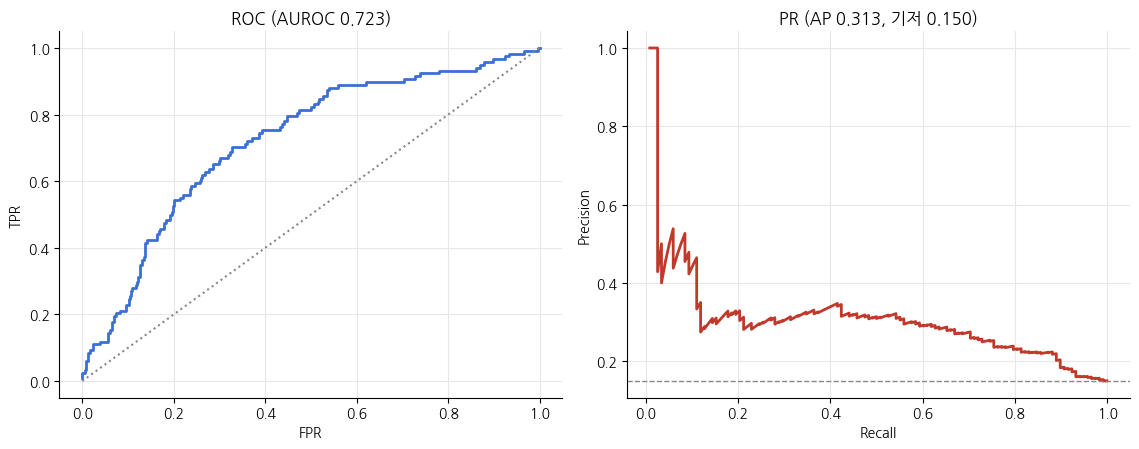

곡선 저장: roc_260731.png


In [38]:
# @title 정답지 채점 (공식 배치)
import csv
import numpy as np

OUT_SCORE_CSV = "정답지_260731_점수.csv"
OUT_ROC_PNG = "roc_260731.png"

assert os.path.exists(ANSWER_CSV), f"정답지 CSV 없음: {ANSWER_CSV}"
assert os.path.isdir(EXT_DIR), f"이미지 폴더 없음: {EXT_DIR}"

def read_answer_csv(path):
    out = {}
    with open(path, encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            name = os.path.basename((row.get("파일") or row.get("파일명") or "").strip())
            if name:
                out[name] = row
    return out

answers = read_answer_csv(ANSWER_CSV)
print(f"정답지 {len(answers)}행 로드  ({ANSWER_CSV})")

ext_paths = sorted(p for p in glob.glob(os.path.join(EXT_DIR, "**", "*"), recursive=True)
                   if p.lower().endswith(IMG_EXTS))
print(f"채점 대상 폴더 {len(ext_paths)}장  ({EXT_DIR})")

ens_models = []
for w in ENS_PATHS:
    m_ = build_mil_resnet().to(DEVICE)
    m_.load_state_dict(torch.load(w, map_location=DEVICE))
    m_.eval()
    ens_models.append(m_)
print(f"앙상블 {len(ens_models)}개로 채점 (k=1, val 기준 선택된 조합)")

scores = {}
for i, p in enumerate(ext_paths):
    vs = [die_topvals(mm, p, DEVICE)[:1].mean(0)[BIN_IDX].item() for mm in ens_models]
    scores[os.path.basename(p)] = float(np.mean(vs))
    if (i + 1) % 200 == 0:
        print(f"  {i + 1}/{len(ext_paths)}")

with open(OUT_SCORE_CSV, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "불량점수"])
    for name in sorted(scores, key=lambda n: -scores[n]):
        wr.writerow([name, f"{scores[name]:.6f}"])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT_SCORE_CSV, "/content/drive/MyDrive/" + OUT_SCORE_CSV)
print(f"\n점수 CSV 저장 완료: {OUT_SCORE_CSV}  ({len(scores)}행)")

matched, unscored, excluded_cnt = [], [], 0
for name, row in answers.items():
    if name not in scores:
        unscored.append(name)
        continue
    target_flag = (row.get("채점대상") or "").strip()
    if target_flag and not target_flag.startswith("예"):
        excluded_cnt += 1
        continue
    label = (row.get("라벨") or "").strip()
    if "불량" in label:
        matched.append((name, scores[name], 1))
    elif "양품" in label:
        matched.append((name, scores[name], 0))
    else:
        excluded_cnt += 1

if unscored:
    print(f"[경고] 정답지에는 있으나 이미지 폴더에 없는 파일 {len(unscored)}건")

n = len(matched)
assert n > 0, "채점 대상과 일치하는 이미지가 없습니다 — 파일명/열 이름 확인"
S_off = np.array([s for _, s, _ in matched])
Y_off = np.array([y for _, _, y in matched])
n_bad_off = int(Y_off.sum())
prev_off = n_bad_off / n
print(f"\n채점 대상 {n}장  (정답지 라벨 기준, 미판정/제외 {excluded_cnt}건)")
print(f"불량 {n_bad_off} / 양품 {n - n_bad_off}  (불량률 {prev_off:.1%})")

order = np.argsort(-S_off)
Ys = Y_off[order]
tp_c = np.cumsum(Ys)
fp_c = np.cumsum(1 - Ys)
P_off, N_off = int(Ys.sum()), n - int(Ys.sum())
tpr_c = tp_c / max(P_off, 1)
fpr_c = fp_c / max(N_off, 1)
auroc = float(np.trapz(tpr_c, fpr_c))

ap_off, tp_r, fp_r = 0.0, 0.0, 0.0
for y in Ys:
    if y:
        tp_r += 1
        ap_off += tp_r / (tp_r + fp_r)
    else:
        fp_r += 1
ap_off /= max(P_off, 1)

def op_top(frac):
    k = max(1, int(round(frac * n)))
    det = int(Ys[:k].sum())
    return k, det / max(P_off, 1), det / k

def op_recall(target_rate):
    ok = np.flatnonzero(tpr_c >= target_rate)
    return (int(ok[0]) + 1, (int(ok[0]) + 1) / n) if len(ok) else None

k10, rec10, prec10 = op_top(0.10)
k25, rec25, prec25 = op_top(0.25)
r90, r95 = op_recall(0.90), op_recall(0.95)
worst_rank = n - int(np.flatnonzero(Ys[::-1])[0]) if P_off else None

print("\n" + "=" * 78)
print(f"[표준 보고표]  정답지_260731 · {n}장 · 불량 {n_bad_off}장 (π={prev_off:.1%})")
print(f"  주지표   AUROC          {auroc:.3f}")
print(f"  보조지표 AP + π         {ap_off:.3f}  (π {prev_off:.3f})")
print(f"  작동점①  상위 10% ({k10}장)   검출률 {rec10:.3f}  정밀도 {prec10:.3f}")
print(f"  작동점②  상위 25% ({k25}장)   검출률 {rec25:.3f}  정밀도 {prec25:.3f}")
print(f"  작동점③  검출률 90%     {r90[0] if r90 else '미달성'}장" +
      (f" ({r90[1]:.1%})" if r90 else ""))
print(f"           검출률 95%     {r95[0] if r95 else '미달성'}장" +
      (f" ({r95[1]:.1%})" if r95 else ""))
print(f"  작동점④  최저 순위(진단) {worst_rank}등 / {n}장")
print(f"  방법     split_seed 42 · 앙상블(k=1) {ENS_PATHS}")
print("=" * 78)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ax = axes[0]
ax.plot(fpr_c, tpr_c, color="#3b6fd4", lw=2)
ax.plot([0, 1], [0, 1], ls=":", color="#888")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title(f"ROC (AUROC {auroc:.3f})")
ax.grid(color="#e5e7eb")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
prec_c = tp_c / np.maximum(tp_c + fp_c, 1e-9)
ax.plot(tpr_c, prec_c, color="#c0392b", lw=2)
ax.axhline(prev_off, color="#888", ls="--", lw=1)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"PR (AP {ap_off:.3f}, 기저 {prev_off:.3f})")
ax.grid(color="#e5e7eb")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_ROC_PNG, dpi=130, bbox_inches="tight")
plt.show()
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT_ROC_PNG, "/content/drive/MyDrive/" + OUT_ROC_PNG)
print(f"곡선 저장: {OUT_ROC_PNG}")

정답지 1030행 로드  (/content/drive/MyDrive/정답지_260721.csv)
채점 대상 폴더 347장  (/content/drive/MyDrive/260721)
  200/347

점수 CSV 저장 완료: 정답지_260721_점수.csv  (347행)
[경고] 정답지에는 있으나 이미지 폴더에 없는 파일 683건

채점 대상 347장  (정답지 라벨 기준, 미판정/제외 0건)
불량 106 / 양품 241  (불량률 30.5%)

[표준 보고표]  정답지_260721(347장 기준) · 347장 · 불량 106장 (π=30.5%)
  주지표   AUROC          0.810
  보조지표 AP + π         0.689  (π 0.305)
  ※ 이 배치는 재현성 확인용 — 260731 결과와 나란히 적으세요


/tmp/ipykernel_2290/2725990124.py:72: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auroc2 = float(np.trapz(tpr2, fpr2))


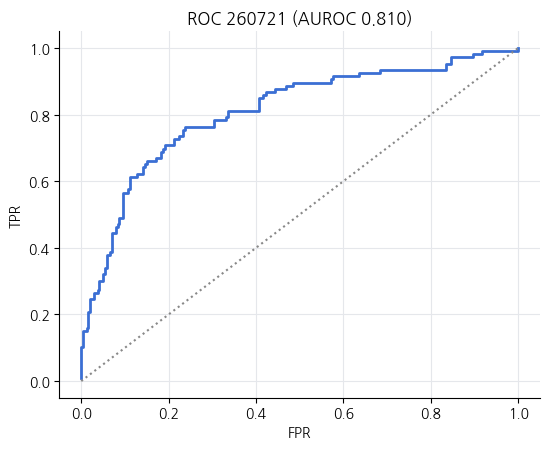

곡선 저장: roc_260721.png


In [39]:
# @title 정답지 채점 (260721 배치)
import csv
import numpy as np

EXT_DIR2 = "/content/drive/MyDrive/260721"
ANSWER_CSV2 = "/content/drive/MyDrive/정답지_260721.csv"
OUT_SCORE_CSV2 = "정답지_260721_점수.csv"
OUT_ROC_PNG2 = "roc_260721.png"

assert os.path.exists(ANSWER_CSV2), f"정답지 CSV 없음: {ANSWER_CSV2}"
assert os.path.isdir(EXT_DIR2), f"이미지 폴더 없음: {EXT_DIR2}"

answers2 = read_answer_csv(ANSWER_CSV2)
print(f"정답지 {len(answers2)}행 로드  ({ANSWER_CSV2})")

ext_paths2 = sorted(p for p in glob.glob(os.path.join(EXT_DIR2, "**", "*"), recursive=True)
                    if p.lower().endswith(IMG_EXTS))
print(f"채점 대상 폴더 {len(ext_paths2)}장  ({EXT_DIR2})")

scores2 = {}
for i, p in enumerate(ext_paths2):
    vs = [die_topvals(mm, p, DEVICE)[:1].mean(0)[BIN_IDX].item() for mm in ens_models]
    scores2[os.path.basename(p)] = float(np.mean(vs))
    if (i + 1) % 200 == 0:
        print(f"  {i + 1}/{len(ext_paths2)}")

with open(OUT_SCORE_CSV2, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "불량점수"])
    for name in sorted(scores2, key=lambda n: -scores2[n]):
        wr.writerow([name, f"{scores2[name]:.6f}"])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT_SCORE_CSV2, "/content/drive/MyDrive/" + OUT_SCORE_CSV2)
print(f"\n점수 CSV 저장 완료: {OUT_SCORE_CSV2}  ({len(scores2)}행)")

matched2, unscored2, excluded_cnt2 = [], [], 0
for name, row in answers2.items():
    if name not in scores2:
        unscored2.append(name)
        continue
    target_flag = (row.get("채점대상") or "").strip()
    if target_flag and not target_flag.startswith("예"):
        excluded_cnt2 += 1
        continue
    label = (row.get("라벨") or "").strip()
    if "불량" in label:
        matched2.append((name, scores2[name], 1))
    elif "양품" in label:
        matched2.append((name, scores2[name], 0))
    else:
        excluded_cnt2 += 1

if unscored2:
    print(f"[경고] 정답지에는 있으나 이미지 폴더에 없는 파일 {len(unscored2)}건")

n2 = len(matched2)
assert n2 > 0, "채점 대상과 일치하는 이미지가 없습니다 — 파일명/열 이름 확인"
S2 = np.array([s for _, s, _ in matched2])
Y2 = np.array([y for _, _, y in matched2])
n_bad2 = int(Y2.sum())
prev2 = n_bad2 / n2
print(f"\n채점 대상 {n2}장  (정답지 라벨 기준, 미판정/제외 {excluded_cnt2}건)")
print(f"불량 {n_bad2} / 양품 {n2 - n_bad2}  (불량률 {prev2:.1%})")

order2 = np.argsort(-S2)
Ys2 = Y2[order2]
tp2 = np.cumsum(Ys2)
fp2 = np.cumsum(1 - Ys2)
P2, N2 = int(Ys2.sum()), n2 - int(Ys2.sum())
tpr2 = tp2 / max(P2, 1)
fpr2 = fp2 / max(N2, 1)
auroc2 = float(np.trapz(tpr2, fpr2))

ap2, tpr_, fpr_ = 0.0, 0.0, 0.0
for y in Ys2:
    if y:
        tpr_ += 1
        ap2 += tpr_ / (tpr_ + fpr_)
    else:
        fpr_ += 1
ap2 /= max(P2, 1)

print("\n" + "=" * 78)
print(f"[표준 보고표]  정답지_260721(347장 기준) · {n2}장 · 불량 {n_bad2}장 (π={prev2:.1%})")
print(f"  주지표   AUROC          {auroc2:.3f}")
print(f"  보조지표 AP + π         {ap2:.3f}  (π {prev2:.3f})")
print("  ※ 이 배치는 재현성 확인용 — 260731 결과와 나란히 적으세요")
print("=" * 78)

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot(fpr2, tpr2, color="#3b6fd4", lw=2)
ax.plot([0, 1], [0, 1], ls=":", color="#888")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title(f"ROC 260721 (AUROC {auroc2:.3f})")
ax.grid(color="#e5e7eb")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_ROC_PNG2, dpi=130, bbox_inches="tight")
plt.show()
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT_ROC_PNG2, "/content/drive/MyDrive/" + OUT_ROC_PNG2)
print(f"곡선 저장: {OUT_ROC_PNG2}")

정상 기준 구축: 학습 양품 1243장 중 300장 사용
  8/300
  88/300
  168/300
  248/300
격자 64x64 | 차원 384 | 기준 구축 완료
점수 계산 중 (val)
점수 계산 중 (test)
[이상 탐지만] test 475장 | 상위 16칸 평균 | thr 9.046 (val에서 고정)
  정확도 0.909 (기준선 0.869)  AP 0.566 (기저 0.131, 4.33배)
  recall 0.484  precision 0.732
  TP 30  FN 32  FP 11  TN 402

[양품 접미사별 과검]
접미사            장수     과검      과검율      평균점수
               62      8    12.9%     4.794
O             159      1     0.6%     3.286
o               4      1    25.0%     5.798
po            188      1     0.5%     3.035

[미검출 겹침]  MIL과 이상 탐지가 같은 것을 놓치는가
  둘 다 놓침       23장
  MIL만 잡음       9장
  이상 탐지만 잡음 5장
  겹치지 않는 14장이 앙상블로 살릴 수 있는 여지입니다


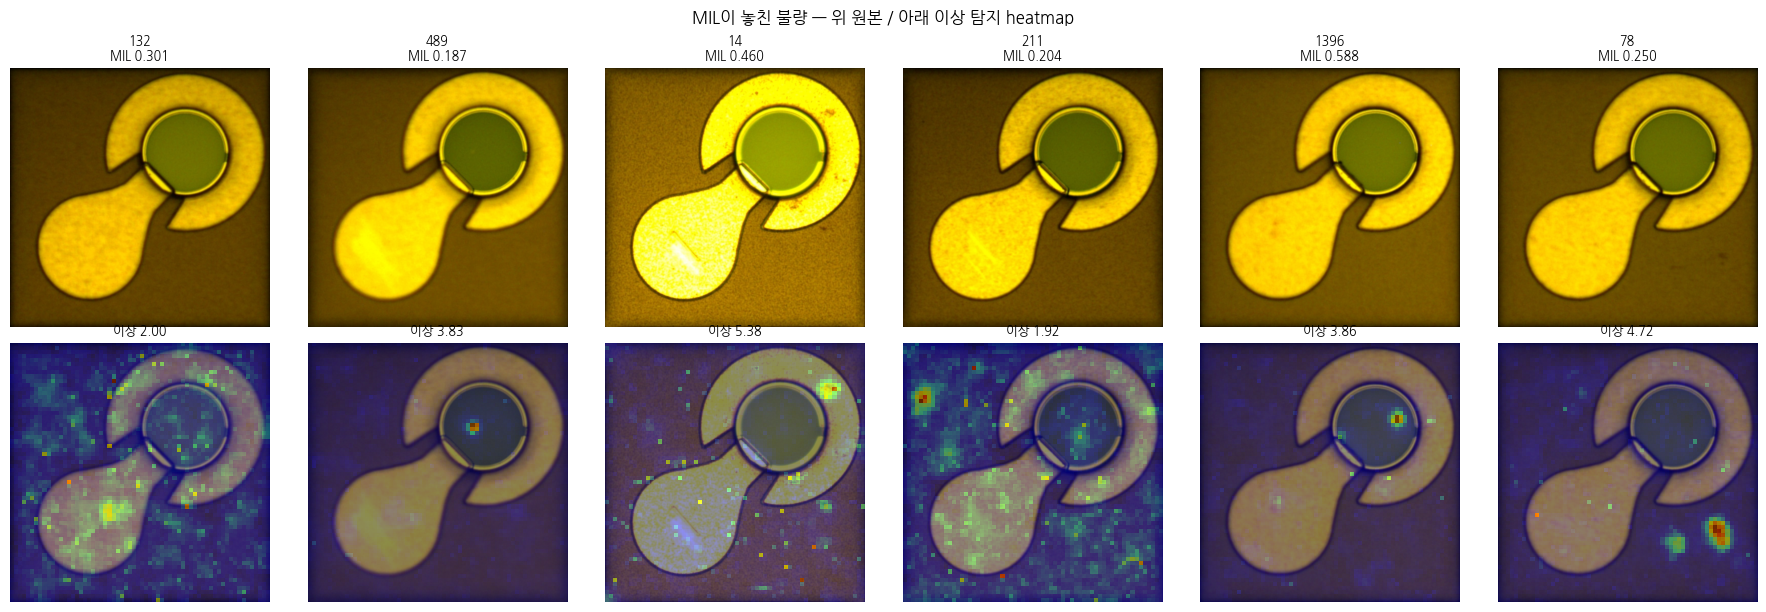

In [40]:
# @title 이상 탐지 (양품만 기준)
import numpy as np
import torch.nn.functional as F
from PIL import Image
from torchvision.models import resnet18, ResNet18_Weights

DIE_BOX = (48, 48, 752, 752)
IN_SIZE = 512
N_FIT = 300
K_ANOM = 16
EPS = 1e-6
BATCH_A = 8

anet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).to(DEVICE).eval()
for q in anet.parameters():
    q.requires_grad_(False)
A_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
A_STD = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

def load_batch(paths):
    arr = []
    for p in paths:
        im = Image.open(p).convert("RGB").crop(DIE_BOX).resize((IN_SIZE, IN_SIZE))
        a = np.asarray(im, dtype=np.float32) / 255.0
        arr.append(torch.from_numpy(a).permute(2, 0, 1))
    return (torch.stack(arr).to(DEVICE) - A_MEAN) / A_STD

@torch.no_grad()
def patch_feat(paths):
    x = load_batch(paths)
    x = anet.maxpool(anet.relu(anet.bn1(anet.conv1(x))))
    x = anet.layer1(x)
    f2 = anet.layer2(x)
    f3 = anet.layer3(f2)
    f3 = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
    f = torch.cat([f2, f3], 1)
    b, c, h, w = f.shape
    return F.normalize(f.permute(0, 2, 3, 1).reshape(b, h * w, c), dim=2), h, w

good_tr = [p for p, g in tr_items if CLASS_NAMES[g] == "양품"]
rsa = np.random.RandomState(0)
pick = rsa.choice(len(good_tr), min(N_FIT, len(good_tr)), replace=False)
fit_paths = [good_tr[i] for i in pick]
print("정상 기준 구축: 학습 양품 %d장 중 %d장 사용" % (len(good_tr), len(fit_paths)), flush=True)

s1 = s2 = None
seen_a = 0
for i in range(0, len(fit_paths), BATCH_A):
    f, ANOM_H, ANOM_W = patch_feat(fit_paths[i:i + BATCH_A])
    f = f.double()
    if s1 is None:
        s1, s2 = torch.zeros_like(f[0]), torch.zeros_like(f[0])
    s1 += f.sum(0)
    s2 += (f * f).sum(0)
    seen_a += f.shape[0]
    if (i // BATCH_A) % 10 == 0:
        print("  %d/%d" % (seen_a, len(fit_paths)), flush=True)
MU = (s1 / seen_a).float()
VAR = (s2 / seen_a - (s1 / seen_a) ** 2).clamp(min=0).float()
print("격자 %dx%d | 차원 %d | 기준 구축 완료" % (ANOM_H, ANOM_W, MU.shape[1]), flush=True)

@torch.no_grad()
def anom_map(path):
    f, h, w = patch_feat([path])
    d = (((f - MU) ** 2) / (VAR + EPS)).mean(2).sqrt()
    return d[0].reshape(h, w).cpu().numpy()

@torch.no_grad()
def anom_scores(items):
    paths = [p for p, _ in items]
    out = []
    for i in range(0, len(paths), BATCH_A):
        f, _, _ = patch_feat(paths[i:i + BATCH_A])
        d = (((f - MU) ** 2) / (VAR + EPS)).mean(2).sqrt()
        out.append(d.topk(K_ANOM, dim=1).values.mean(1).cpu())
    return torch.cat(out)

def ap_of(sc, lab):
    order = np.argsort(-sc)
    tp = fp = ap = 0.0
    for i in order:
        if lab[i]:
            tp += 1
            ap += tp / (tp + fp)
        else:
            fp += 1
    return ap / max(lab.sum(), 1)

def acc_at(sc, lab, t):
    pr = sc >= t
    return float(((pr & lab) | (~pr & ~lab)).mean())

def best_t(sc, lab):
    cand = np.unique(sc)
    return float(max(cand, key=lambda t: acc_at(sc, lab, t)))

print("점수 계산 중 (val)", flush=True)
ANOM_VA = anom_scores(va_items).numpy()
print("점수 계산 중 (test)", flush=True)
ANOM_TE = anom_scores(te_items).numpy()

lab_va = (Y_va[:, BIN_IDX] > 0).numpy()
lab_te = (Y[:, BIN_IDX] > 0).numpy()
t_an = best_t(ANOM_VA, lab_va)
acc_an = acc_at(ANOM_TE, lab_te, t_an)
ap_an = ap_of(ANOM_TE, lab_te)
pr_an = ANOM_TE >= t_an
tp_a = int((pr_an & lab_te).sum())
fn_a = int((~pr_an & lab_te).sum())
fp_a = int((pr_an & ~lab_te).sum())
tn_a = int((~pr_an & ~lab_te).sum())
base_a = 1 - lab_te.mean()

print("=" * 76)
print("[이상 탐지만] test %d장 | 상위 %d칸 평균 | thr %.3f (val에서 고정)"
      % (len(lab_te), K_ANOM, t_an))
print("  정확도 %.3f (기준선 %.3f)  AP %.3f (기저 %.3f, %.2f배)"
      % (acc_an, base_a, ap_an, lab_te.mean(), ap_an / max(lab_te.mean(), 1e-9)))
print("  recall %.3f  precision %.3f"
      % (tp_a / max(tp_a + fn_a, 1), tp_a / max(tp_a + fp_a, 1)))
print("  TP %d  FN %d  FP %d  TN %d" % (tp_a, fn_a, fp_a, tn_a))

print("")
print("[양품 접미사별 과검]")
print("%-10s %6s %6s %8s %9s" % ("접미사", "장수", "과검", "과검율", "평균점수"))
sufs = [suffix_of(p) for p, _ in te_items]
for s_ in sorted(set(sufs[i] for i in range(len(sufs)) if not lab_te[i])):
    idx = [i for i in range(len(sufs)) if sufs[i] == s_ and not lab_te[i]]
    k = sum(1 for i in idx if pr_an[i])
    print("%-10s %6d %6d %7.1f%% %9.3f"
          % (s_, len(idx), k, 100 * k / len(idx),
             float(np.mean([ANOM_TE[i] for i in idx]))))

mil_te = S[:, BIN_IDX].numpy()
mil_pr = mil_te >= THR_BIN
both_fn = int((~pr_an & ~mil_pr & lab_te).sum())
only_mil = int((~pr_an & mil_pr & lab_te).sum())
only_an = int((pr_an & ~mil_pr & lab_te).sum())
print("")
print("[미검출 겹침]  MIL과 이상 탐지가 같은 것을 놓치는가")
print("  둘 다 놓침       %d장" % both_fn)
print("  MIL만 잡음       %d장" % only_mil)
print("  이상 탐지만 잡음 %d장" % only_an)
print("  겹치지 않는 %d장이 앙상블로 살릴 수 있는 여지입니다" % (only_mil + only_an))
print("=" * 76)

show = [i for i in range(len(lab_te)) if lab_te[i] and not mil_pr[i]][:6]
if show:
    fig, axes = plt.subplots(2, len(show), figsize=(3.0 * len(show), 6.2))
    axes = np.atleast_2d(axes)
    for c, i in enumerate(show):
        path = te_items[i][0]
        im = Image.open(path).convert("RGB").crop(DIE_BOX)
        axes[0, c].imshow(im)
        axes[0, c].set_title("%s\nMIL %.3f" % (os.path.basename(path).split("-")[0],
                                               mil_te[i]), fontsize=9)
        axes[0, c].axis("off")
        axes[1, c].imshow(im)
        axes[1, c].imshow(anom_map(path), cmap="jet", alpha=0.45,
                          extent=(0, im.size[0], im.size[1], 0))
        axes[1, c].set_title("이상 %.2f" % ANOM_TE[i], fontsize=9)
        axes[1, c].axis("off")
    fig.suptitle("MIL이 놓친 불량 — 위 원본 / 아래 이상 탐지 heatmap", fontsize=12)
    plt.tight_layout()
    plt.show()

In [41]:
# @title 이상 탐지 + MIL 앙상블
import numpy as np

mil_va = S_va[:, BIN_IDX].numpy()
mil_te = S[:, BIN_IDX].numpy()
lab_va = (Y_va[:, BIN_IDX] > 0).numpy()
lab_te = (Y[:, BIN_IDX] > 0).numpy()

def zfit(v):
    return float(v.mean()), float(v.std() + 1e-9)

m_mu, m_sd = zfit(mil_va)
a_mu, a_sd = zfit(ANOM_VA)
zm_va, zm_te = (mil_va - m_mu) / m_sd, (mil_te - m_mu) / m_sd
za_va, za_te = (ANOM_VA - a_mu) / a_sd, (ANOM_TE - a_mu) / a_sd

rows = []
for w in np.arange(0.0, 1.01, 0.05):
    cv = w * zm_va + (1 - w) * za_va
    ct = w * zm_te + (1 - w) * za_te
    t = best_t(cv, lab_va)
    pr = ct >= t
    tp_ = int((pr & lab_te).sum())
    fn_ = int((~pr & lab_te).sum())
    fp_ = int((pr & ~lab_te).sum())
    tn_ = int((~pr & ~lab_te).sum())
    rows.append((float(w), acc_at(cv, lab_va, t), t, acc_at(ct, lab_te, t),
                 ap_of(ct, lab_te), tp_ / max(tp_ + fn_, 1),
                 tp_ / max(tp_ + fp_, 1), fn_, fp_))

print("=" * 84)
print("w = MIL 가중치 (w=1 은 MIL만, w=0 은 이상 탐지만)")
print("%5s %9s %8s %11s %8s %8s %10s %7s %6s"
      % ("w", "val정확도", "thr", "test정확도", "test AP", "recall", "precision",
         "미검출", "과검"))
best_row = max(rows, key=lambda r: r[1])
for r in rows:
    mark = "  <- val 기준 선택" if r is best_row else ""
    print("%5.2f %9.3f %8.3f %11.3f %8.3f %8.3f %10.3f %7d %6d%s"
          % (r[0], r[1], r[2], r[3], r[4], r[5], r[6], r[7], r[8], mark))
print("-" * 84)
print("선택 w %.2f  ->  test 정확도 %.3f / AP %.3f / 미검출 %d장 / 과검 %d장"
      % (best_row[0], best_row[3], best_row[4], best_row[7], best_row[8]))
need = int(np.ceil(0.9 * len(lab_te))) - int(round(best_row[3] * len(lab_te)))
print("정확도 0.9까지 %d장 부족" % max(need, 0))
print("=" * 84)

w = MIL 가중치 (w=1 은 MIL만, w=0 은 이상 탐지만)
    w    val정확도      thr     test정확도  test AP   recall  precision     미검출     과검
 0.00     0.899    1.547       0.909    0.566    0.484      0.732      32     11
 0.05     0.905    1.190       0.909    0.582    0.516      0.711      30     13
 0.10     0.909    1.245       0.912    0.602    0.532      0.717      29     13
 0.15     0.912    1.175       0.912    0.619    0.532      0.717      29     13
 0.20     0.914    1.444       0.914    0.638    0.516      0.744      30     11
 0.25     0.914    1.360       0.916    0.656    0.532      0.750      29     11
 0.30     0.916    1.330       0.916    0.672    0.532      0.750      29     11
 0.35     0.918    1.004       0.912    0.688    0.565      0.700      27     15
 0.40     0.920    1.100       0.916    0.703    0.581      0.720      26     14
 0.45     0.924    1.383       0.928    0.717    0.565      0.833      27      7
 0.50     0.926    1.379       0.931    0.730    0.581      0.837     